# Assignment 1: EDA
**Referensi**: "An active learning machine technique based prediction of cardiovascular heart disease from UCI-repository database" (Scientific Reports, 2023).<br>

#### Load Data

In [1]:
# fetch data
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path('.\\heart+disease')
FILE_NAMES = [
    "processed.cleveland.data",
    "processed.hungarian.data",
    "processed.switzerland.data",
    "processed.va.data",
]
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

frames = []
for file_name in FILE_NAMES:
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {file_path}")
    frame = pd.read_csv(file_path, header=None, names=FEATURE_NAMES, na_values="?")
    frame["source_file"] = file_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df[FEATURE_NAMES] = df[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
df["target_binary"] = (df["target"] > 0).astype("Int64")

print(f"Dataset berhasil dimuat: {df.shape[0]:,} observasi, {len(FEATURE_NAMES):,} fitur asli")
display(df.head())

Dataset berhasil dimuat: 920 observasi, 14 fitur asli


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source_file,target_binary
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,processed.cleveland.data,0


#### Re-classify target to binary

In [2]:
# initial `target` has range 0-4, but for prediction task we re-classify to binary 
# (0 = Healthy and 1 = heart disease (target > 0))
df_a1 = df.copy()
df_a1.drop(columns=["target"], inplace=True)
df_a1.rename(columns={"target_binary": "target"}, inplace=True)
df_a1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0


In [3]:
df_a1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          920 non-null    float64
 1   sex          920 non-null    float64
 2   cp           920 non-null    float64
 3   trestbps     861 non-null    float64
 4   chol         890 non-null    float64
 5   fbs          830 non-null    float64
 6   restecg      918 non-null    float64
 7   thalach      865 non-null    float64
 8   exang        865 non-null    float64
 9   oldpeak      858 non-null    float64
 10  slope        611 non-null    float64
 11  ca           309 non-null    float64
 12  thal         434 non-null    float64
 13  source_file  920 non-null    object 
 14  target       920 non-null    Int64  
dtypes: Int64(1), float64(13), object(1)
memory usage: 108.8+ KB


#### Data Understanding

In [4]:
print("1. JUMLAH OBSERVASI DAN FITUR")
print(f"Observasi: {len(df_a1):,}")
print(f"Fitur asli: {len(FEATURE_NAMES) - 1:,} | Target: 1 | Kolom metadata: source_file, target_binary")

1. JUMLAH OBSERVASI DAN FITUR
Observasi: 920
Fitur asli: 13 | Target: 1 | Kolom metadata: source_file, target_binary


In [5]:
print("\n2. TIPE SETIAP FITUR")
type_table = pd.DataFrame({
    "feature": df_a1[FEATURE_NAMES].columns,
    "dtype": df_a1[FEATURE_NAMES].dtypes.astype(str).values,
    "n_unique": df_a1[FEATURE_NAMES].nunique(dropna=True).values,
})
display(type_table)


2. TIPE SETIAP FITUR


,feature,dtype,n_unique
0,age,float64,50
1,sex,float64,2
2,cp,float64,4
3,trestbps,float64,61
4,chol,float64,217
5,fbs,float64,2
6,restecg,float64,3
7,thalach,float64,119
8,exang,float64,2
9,oldpeak,float64,53


3. DISTRIBUSI TARGET


,count,percentage
target,,
0,411,44.674
1,509,55.326


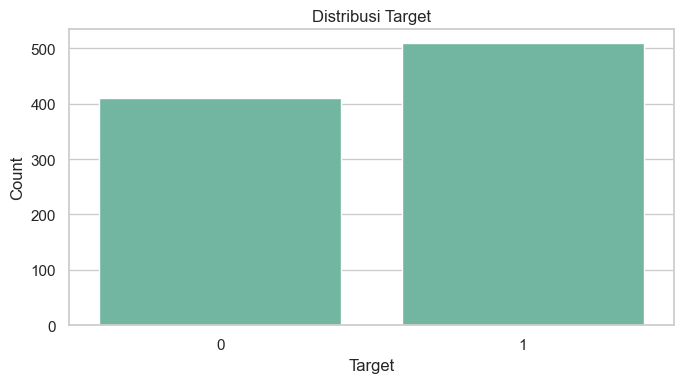

In [6]:
print("3. DISTRIBUSI TARGET")
target_distribution = pd.DataFrame({
    "count": df_a1["target"].value_counts(dropna=False).sort_index(),
    "percentage": df_a1["target"].value_counts(normalize=True, dropna=False).sort_index().mul(100),
})
display(target_distribution)
plt.figure(figsize=(7, 4))
sns.countplot(data=df_a1, x="target")
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
print("4. MISSING VALUES")
missing_table = pd.DataFrame({
    "missing_count": df_a1[FEATURE_NAMES].isna().sum(),
    "missing_percentage": df_a1[FEATURE_NAMES].isna().mean().mul(100),
}).sort_values("missing_count", ascending=False)
display(missing_table)

4. MISSING VALUES


,missing_count,missing_percentage
ca,611,66.413
thal,486,52.826
slope,309,33.587
fbs,90,9.783
oldpeak,62,6.739
trestbps,59,6.413
thalach,55,5.978
exang,55,5.978
chol,30,3.261
restecg,2,0.217


In [8]:
print("5. DUPLICATE RECORDS")
print(f"Duplikat penuh (tanpa source_file): {df_a1[FEATURE_NAMES].duplicated().sum():,}")
print(f"Duplikat fitur dengan target berbeda: {df_a1.duplicated(FEATURE_NAMES[:-1], keep=False).sum():,} baris")
print(f"Duplikat identik antar semua kolom: {df_a1.duplicated().sum():,}")

5. DUPLICATE RECORDS
Duplikat penuh (tanpa source_file): 2
Duplikat fitur dengan target berbeda: 4 baris
Duplikat identik antar semua kolom: 2


6. DISTRIBUSI NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,920.000,53.511,9.425,28.000,47.000,54.000,60.000,77.000
trestbps,861.000,132.132,19.066,0.000,120.000,130.000,140.000,200.000
chol,890.000,199.130,110.781,0.000,175.000,223.000,268.000,603.000
thalach,865.000,137.546,25.926,60.000,120.000,140.000,157.000,202.000
oldpeak,858.000,0.879,1.091,-2.600,0.000,0.500,1.500,6.200


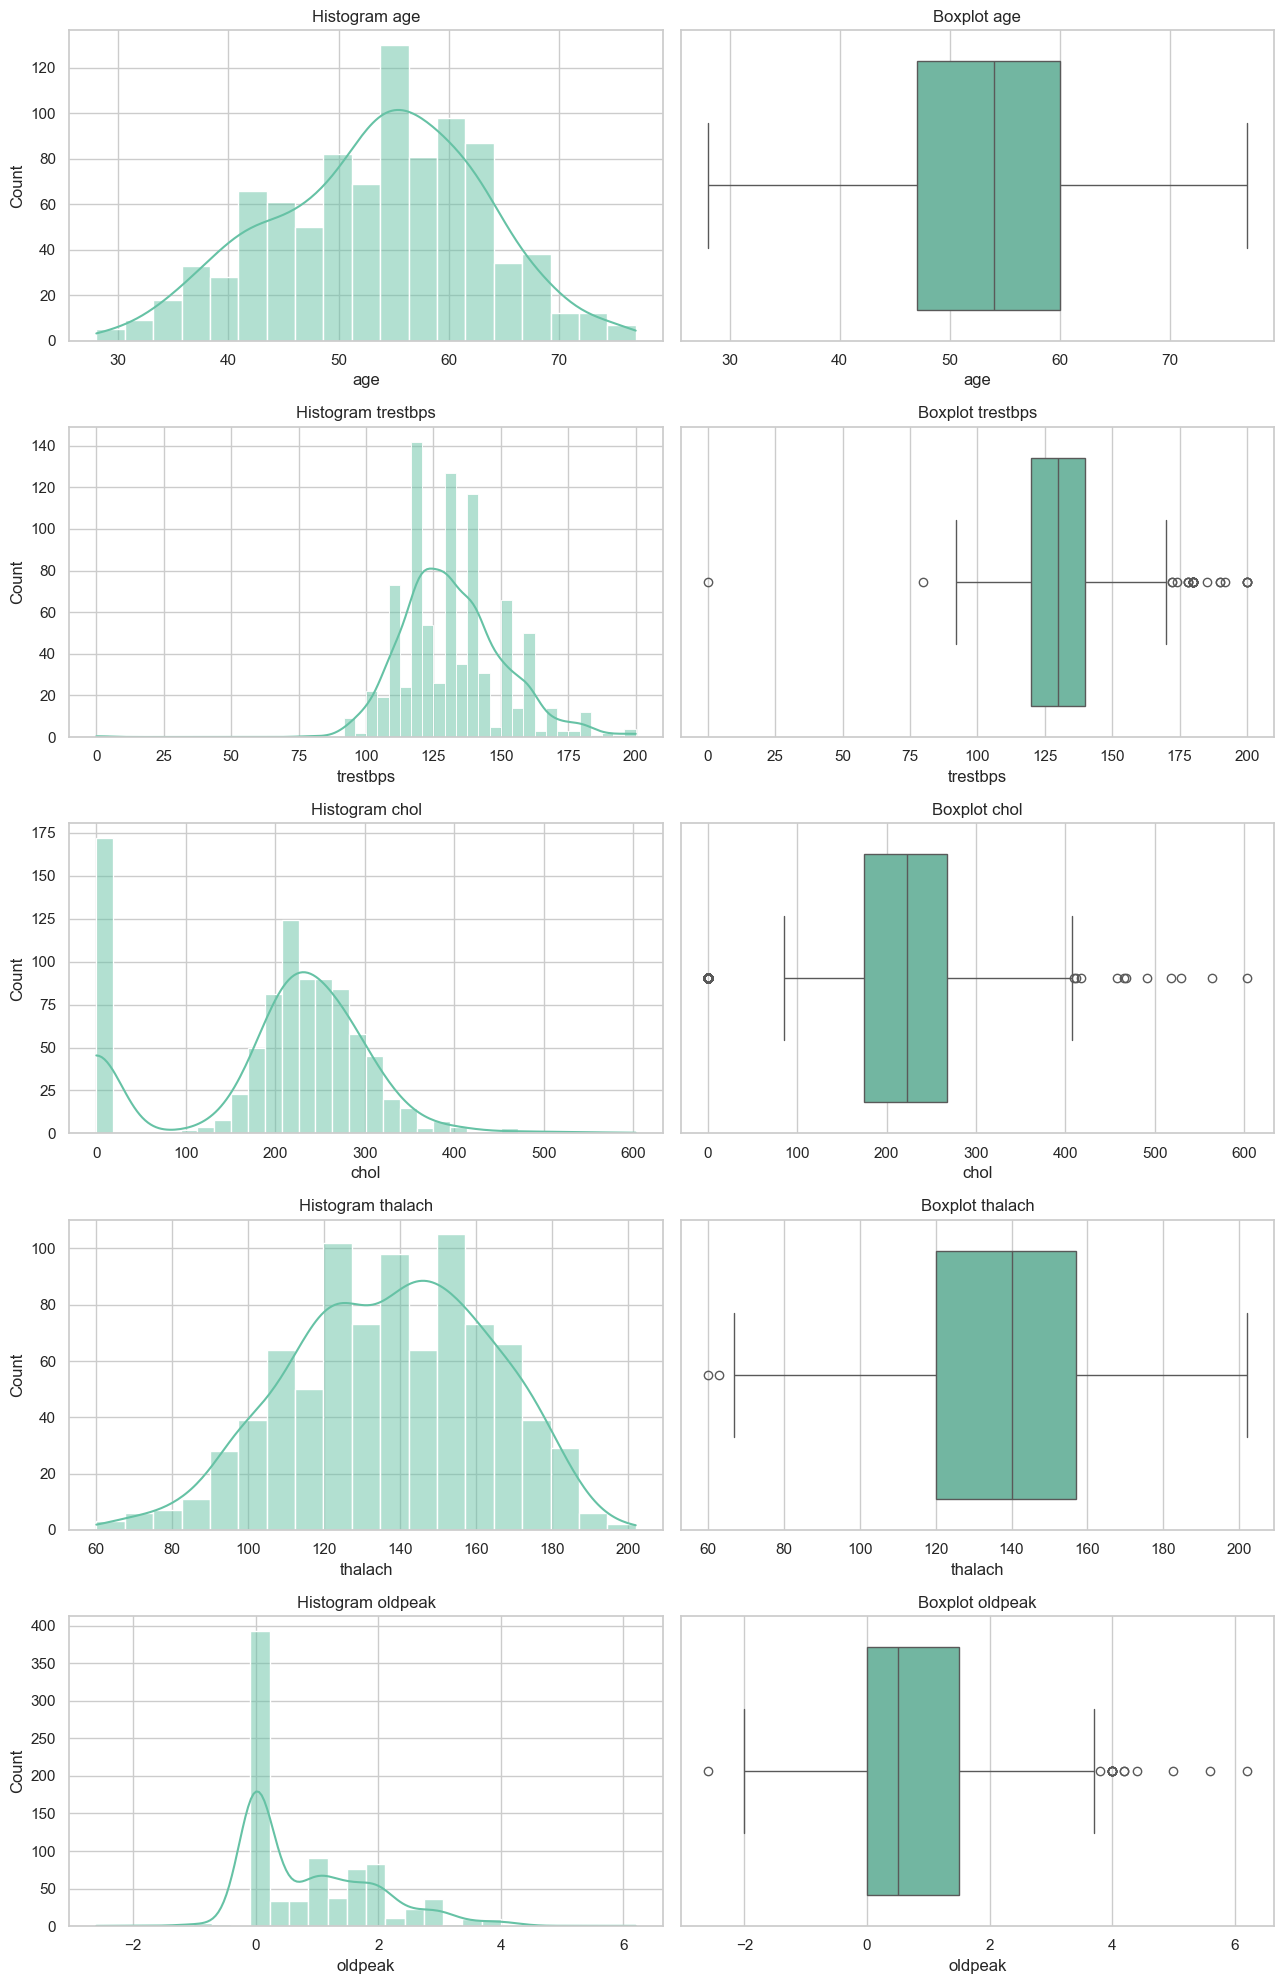

In [9]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("6. DISTRIBUSI NUMERICAL FEATURES")
display(df_a1[numeric_features].describe().T)
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(13, 4 * len(numeric_features)))
for row, feature in enumerate(numeric_features):
    sns.histplot(data=df_a1, x=feature, kde=True, ax=axes[row, 0])
    axes[row, 0].set_title(f"Histogram {feature}")
    sns.boxplot(data=df_a1, x=feature, ax=axes[row, 1])
    axes[row, 1].set_title(f"Boxplot {feature}")
plt.tight_layout()
plt.show()

7. DISTRIBUSI CATEGORICAL FEATURES

sex


,count,percentage
sex,,
1.000,726,78.913
0.000,194,21.087


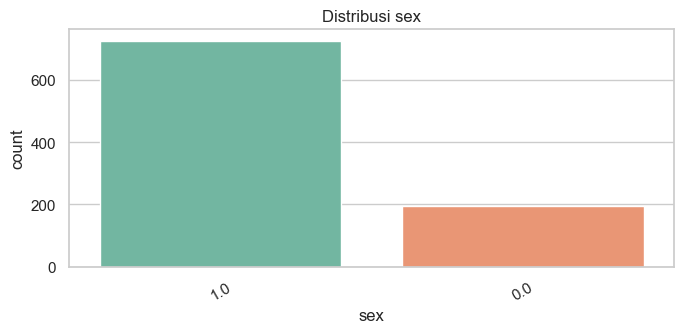


cp


,count,percentage
cp,,
4.000,496,53.913
3.000,204,22.174
2.000,174,18.913
1.000,46,5.000


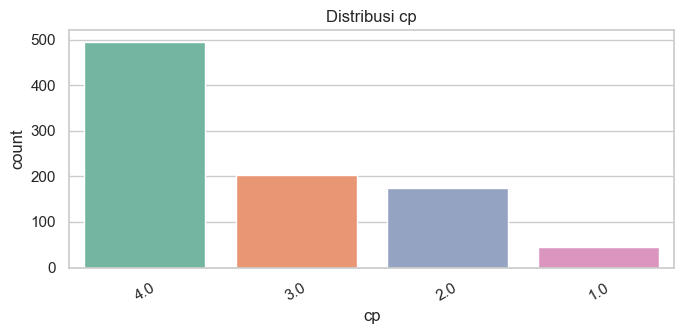


fbs


,count,percentage
fbs,,
0.000,692,75.217
1.000,138,15.000
NaN,90,9.783


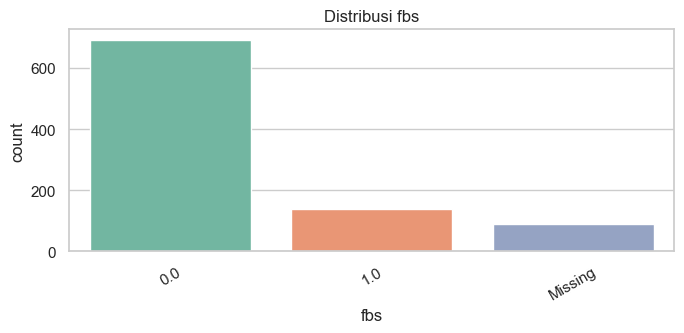


restecg


,count,percentage
restecg,,
0.000,551,59.891
2.000,188,20.435
1.000,179,19.457
NaN,2,0.217


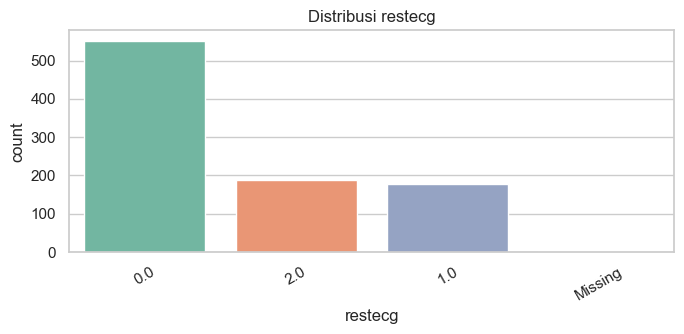


exang


,count,percentage
exang,,
0.000,528,57.391
1.000,337,36.630
NaN,55,5.978


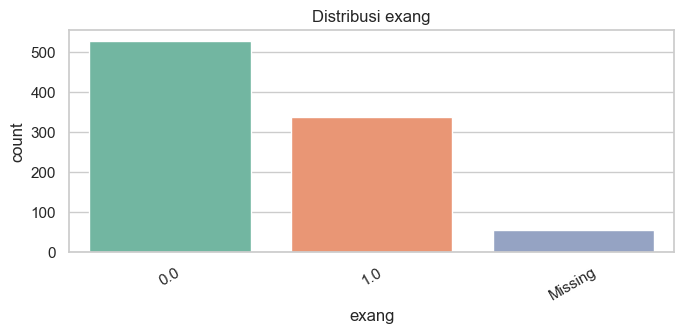


slope


,count,percentage
slope,,
2.000,345,37.500
NaN,309,33.587
1.000,203,22.065
3.000,63,6.848


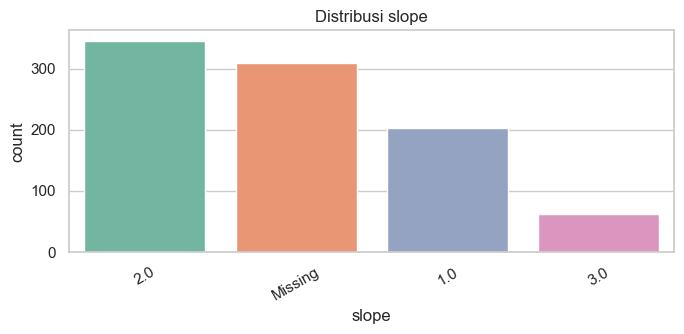


ca


,count,percentage
ca,,
NaN,611,66.413
0.000,181,19.674
1.000,67,7.283
2.000,41,4.457
3.000,20,2.174


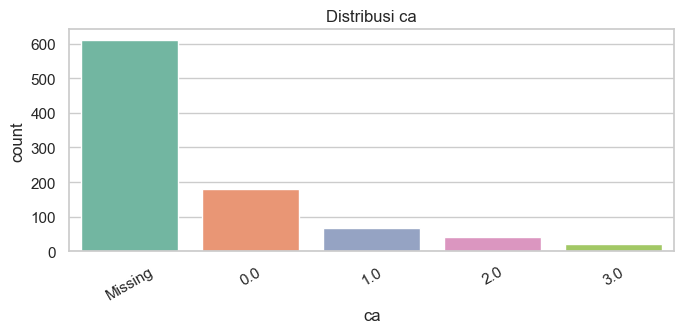


thal


,count,percentage
thal,,
NaN,486,52.826
3.000,196,21.304
7.000,192,20.870
6.000,46,5.000


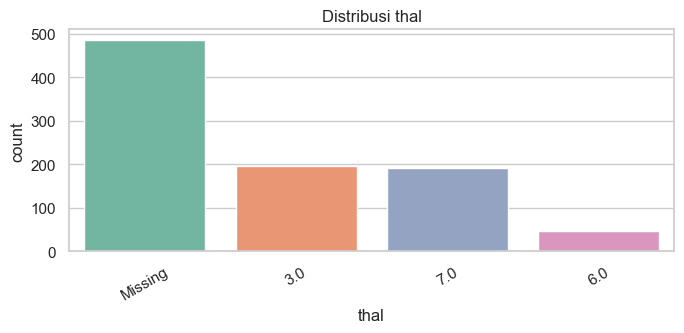

In [10]:
print("7. DISTRIBUSI CATEGORICAL FEATURES")
for feature in categorical_features:
    distribution = df_a1[feature].value_counts(dropna=False).rename_axis(feature).to_frame("count")
    distribution["percentage"] = distribution["count"].div(len(df_a1)).mul(100)
    print(f"\n{feature}")
    display(distribution)

    # HANYA untuk plotting - df[feature] asli tidak disentuh
    plot_series = df_a1[feature].astype(str).where(df_a1[feature].notna(), "Missing")
    plot_order = plot_series.value_counts(dropna=False).index

    plt.figure(figsize=(7, 3.5))
    sns.countplot(
        x=plot_series,
        order=plot_order,
        hue=plot_series,
        hue_order=plot_order,
        palette="Set2",
    )
    plt.legend([], [], frameon=False)
    plt.title(f"Distribusi {feature}")
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [11]:
print("8. ANOMALOUS VALUES (ATURAN DOMAIN)")
domain_rules = {
    "age": (0, 120),
    "sex": (0, 1),
    "cp": (1, 4),
    "trestbps": (50, 250),
    "chol": (50, 700),
    "fbs": (0, 1),
    "restecg": (0, 2),
    "thalach": (50, 250),
    "exang": (0, 1),
    "oldpeak": (-5, 10),
    "slope": (1, 3),
    "ca": (0, 3),
    "thal": (3, 7),
    "target": (0, 1),
}
anomaly_rows = []
for feature, (lower, upper) in domain_rules.items():
    values = pd.to_numeric(df_a1[feature], errors="coerce")
    mask = values.notna() & ~values.between(lower, upper)
    anomaly_rows.append({
        "feature": feature,
        "allowed_range": f"[{lower}, {upper}]",
        "anomaly_count": int(mask.sum()),
        "anomaly_percentage": mask.mean() * 100,
    })
anomaly_table = pd.DataFrame(anomaly_rows).sort_values("anomaly_count", ascending=False)
display(anomaly_table)
print("Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.")

8. ANOMALOUS VALUES (ATURAN DOMAIN)


,feature,allowed_range,anomaly_count,anomaly_percentage
4,chol,"[50, 700]",172,18.696
3,trestbps,"[50, 250]",1,0.109
1,sex,"[0, 1]",0,0.000
0,age,"[0, 120]",0,0.000
2,cp,"[1, 4]",0,0.000
5,fbs,"[0, 1]",0,0.000
6,restecg,"[0, 2]",0,0.000
7,thalach,"[50, 250]",0,0.000
8,exang,"[0, 1]",0,0.000
9,oldpeak,"[-5, 10]",0,0.000


Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.


9. OUTLIER ANALYSIS (IQR)


,feature,q1,q3,lower_bound,upper_bound,outlier_count,outlier_percentage
2,chol,175.000,268.000,35.500,407.500,183,19.891
1,trestbps,120.000,140.000,90.000,170.000,28,3.043
4,oldpeak,0.000,1.500,-2.250,3.750,16,1.739
3,thalach,120.000,157.000,64.500,212.500,2,0.217
0,age,47.000,60.000,27.500,79.500,0,0.000


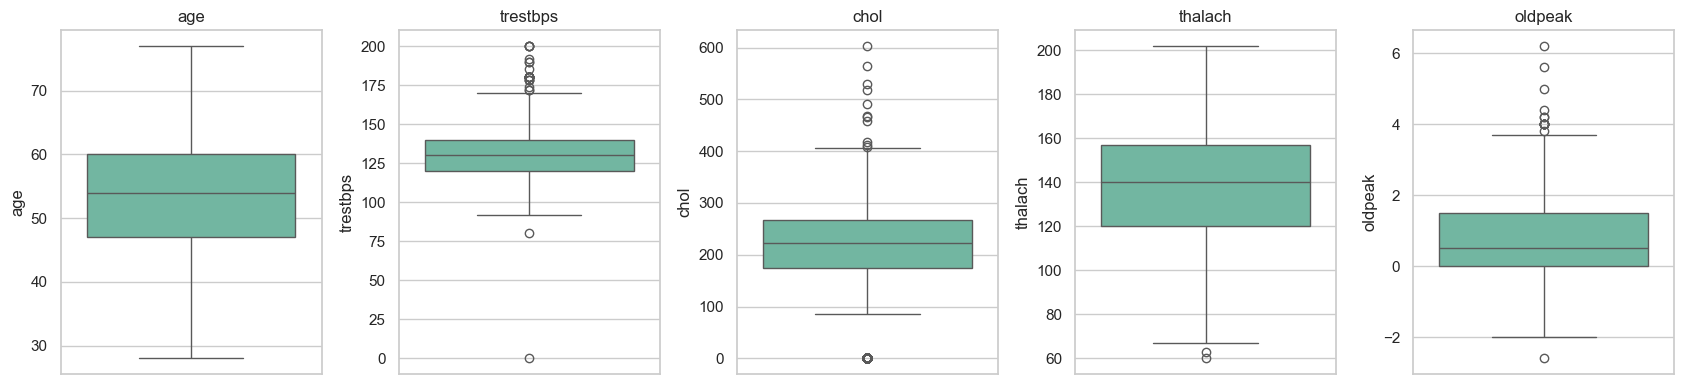

In [12]:
print("9. OUTLIER ANALYSIS (IQR)")
outlier_rows = []
for feature in numeric_features:
    values = df_a1[feature].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = df_a1[feature].notna() & ~df_a1[feature].between(lower, upper)
    outlier_rows.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percentage": mask.mean() * 100,
    })
outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_table)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(17, 4))
for axis, feature in zip(axes, numeric_features):
    sns.boxplot(data=df, y=feature, ax=axis)
    axis.set_title(feature)
plt.tight_layout()
plt.show()

10. HUBUNGAN FEATURE DENGAN TARGET
Rata-rata fitur numerik berdasarkan target biner:


target                0       1       2       3       4
age      count  411.000 265.000 109.000 107.000  28.000
         mean    50.547  53.528  57.578  59.215  59.214
         median  51.000  55.000  58.000  60.000  59.000
trestbps count  391.000 252.000 101.000  92.000  25.000
         mean   129.913 132.861 133.614 136.152 138.720
         median 130.000 130.000 134.000 135.000 136.000
chol     count  392.000 258.000 107.000 106.000  27.000
         mean   227.906 195.256 143.860 159.717 192.148
         median 228.000 229.000 193.000 213.000 225.000
thalach  count  391.000 252.000 102.000  94.000  26.000
         mean   148.801 131.036 128.667 120.500 127.846
         median 151.000 130.000 130.000 120.000 125.000
oldpeak  count  390.000 250.000 101.000  91.000  26.000
         mean     0.418   1.001   1.353   1.581   2.308
         median   0.000   1.000   1.500   1.500   2.500

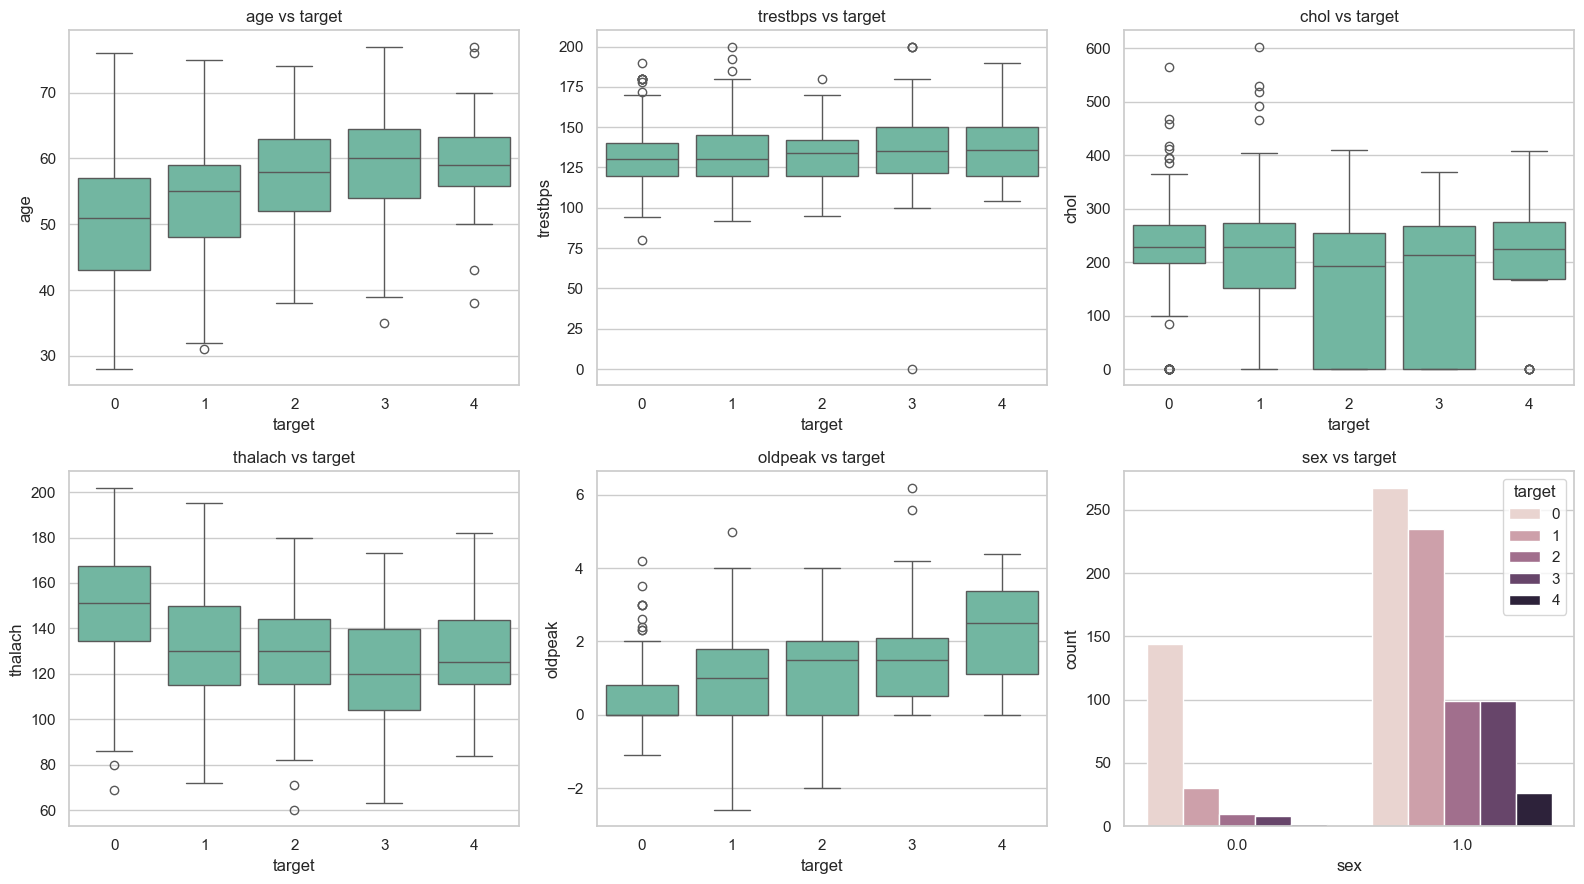


Positive rate berdasarkan sex


,count,positive_rate
sex,,
0.000,194,0.423
1.000,726,1.149



Positive rate berdasarkan cp


,count,positive_rate
cp,,
1.000,46,0.717
2.000,174,0.184
3.000,204,0.662
4.000,496,1.444



Positive rate berdasarkan fbs


...

,count,positive_rate
slope,,
1.000,203,0.690
2.000,345,1.354
3.000,63,1.746
NaN,309,0.644



Positive rate berdasarkan ca


,count,positive_rate
ca,,
0.000,181,0.453
1.000,67,1.299
2.000,41,1.902
3.000,20,2.300
NaN,611,1.020



Positive rate berdasarkan thal


,count,positive_rate
thal,,
3.000,196,0.520
6.000,46,1.522
7.000,192,1.615
NaN,486,0.893


In [13]:
print("10. HUBUNGAN FEATURE DENGAN TARGET")
print("Rata-rata fitur numerik berdasarkan target biner:")
display(df.groupby("target")[numeric_features].agg(["count", "mean", "median"]).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, feature in zip(axes.flat, numeric_features):
    sns.boxplot(data=df, x="target", y=feature, ax=axis)
    axis.set_title(f"{feature} vs target")
for axis, feature in zip(axes.flat[len(numeric_features):], categorical_features[:1]):
    sns.countplot(data=df, x=feature, hue="target", ax=axis)
    axis.set_title(f"{feature} vs target")
for axis in axes.flat[(len(numeric_features) + 1):]:
    axis.axis("off")
plt.tight_layout()
plt.show()

for feature in categorical_features:
    rates = df.groupby(feature, dropna=False)["target"].agg(["count", "mean"])
    rates = rates.rename(columns={"mean": "positive_rate"})
    print(f"\nPositive rate berdasarkan {feature}")
    display(rates)

11. CORRELATION ANALYSIS


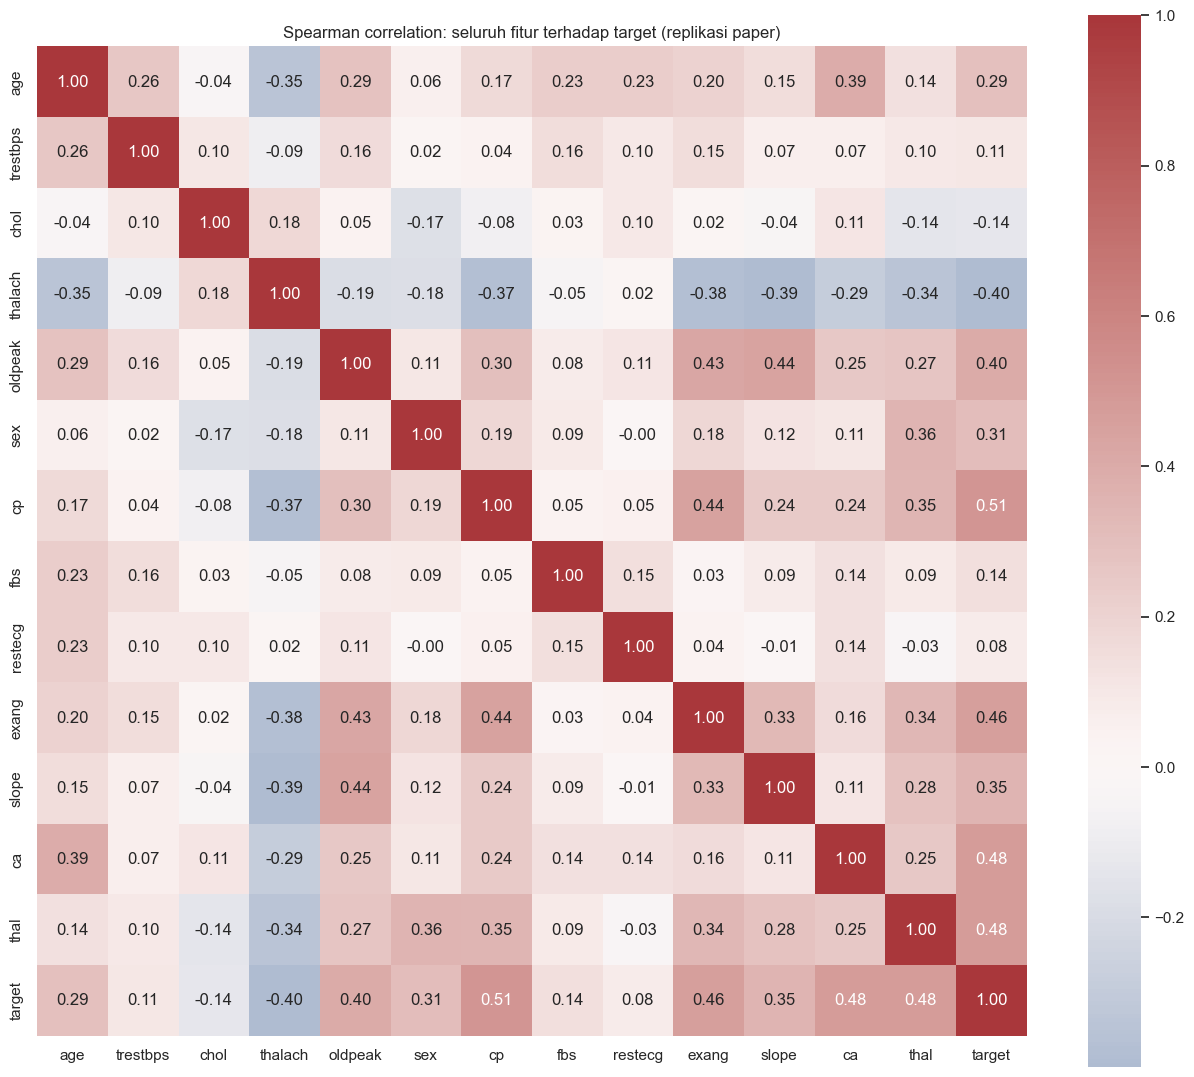

Korelasi Spearman terhadap target (seluruh fitur):


,spearman_corr
cp,0.511
ca,0.484
thal,0.484
exang,0.464
oldpeak,0.401
thalach,-0.399
slope,0.353
sex,0.307
age,0.291
fbs,0.143


In [14]:
print("11. CORRELATION ANALYSIS")

# Replikasi paper: seluruh fitur (numerik + kategorikal) dihitung dengan Spearman,
# tanpa membedakan skala data --> mengikuti pendekatan paper aslinya apa adanya.
correlation_columns = numeric_features + categorical_features + ["target"]
correlation_matrix = df_a1[correlation_columns].corr(method="spearman")

plt.figure(figsize=(13, 11))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlation: seluruh fitur terhadap target (replikasi paper)")
plt.tight_layout()
plt.show()

print("Korelasi Spearman terhadap target (seluruh fitur):")
display(correlation_matrix["target"].drop("target").sort_values(key=abs, ascending=False).to_frame("spearman_corr"))

# Assignment 2: Replication Paper

#### Design

**2. 1. Methodology Audit and Replication Design**

**Goals**: Replikasi paper sedekat mungkin sambil menjaga integritas pipeline data dan mencegah data leakage. <br>
**Rekonstruksi**:
Data
→ preprocessing
→ feature selection/engineering
→ train-test split
→ model training
→ evaluation. <br>

Berdasarkan informasi yang tersedia, paper melaporkan bahwa dataset UCI digunakan untuk prediksi penyakit jantung, lalu dilakukan preprocessing, split data, pelatihan model, dan evaluasi akurasi. Namun, paper tidak menjelaskan secara konsisten: sumber dataset yang tepat, filtering yang dilakukan, prosedur imputation dan scaling yang digunakan, random seed, serta detail hyperparameter untuk sebagian besar model. Karena informasi tersebut tidak lengkap, replikasi harus dibatasi pada interpretasi yang didukung oleh data dan metodologi yang masuk akal.

**2. 2. Methodological Issues, Ambiguities, and Decisions**
1. Dataset <br>
Paper (503 observations dan 10 attributes), dataset UCI tersedia (920 observasi, 13 atribut) tidak dapat direkonstruksi identik. <br> Karena tidak ada informasi lengkap tentang filtering, exclusion, atau langkah preprocessing yang menghasilkan 503 observasi. Ini dicatat sebagai reproducibility limitation. <br>

2. Features
- *10 predictors used*:
  - sex
  - age
  - cp
  - trestbps
  - chol
  - fbs
  - restecg
  - thalach
  - exang
  - oldpeak

- *3 attributes dropped (due to missing values rate)*:
  - slope
  - ca
  - thal <br>

3. Target <br>
Target ditetapkan sebagai binary: num = 0 -> normal (0), num > 0 -> diseased (1). <br>
Jika target_binary sudah dibuat maka kita gunakan yang sudah ada dan tidak membuat duplikat. <br>

4. Train-test split <br>
Paper inkonsistensi: Proposed Methodology menyebut sekitar 70% training/30% testing, sedangkan Proposed Model Overview menyebut 75% training/25% testing. <br> Untuk corrected replication utama, kita menggunakan 70:30 karena disebut pada bagian Proposed Methodology. Split dilakukan dengan stratification dan random_state=42 sebagai reproducibility assumption karena paper tidak melaporkan seed. <br>

5. Missing values <br>
Paper mengatakan missing values ditangani menggunakan mean. Namun corrected replication harus mencegah data leakage: split dilakukan sebelum fitting imputation, <br> imputer hanya fit pada X_train, lalu transform X_train dan X_test. Untuk numerical continuous features kita gunakan mean imputation. Untuk categorical/binary features, jika mean imputation tidak metodologis, kita gunakan most_frequent dan dokumentasikan sebagai methodological correction. <br>

6. Scaling <br>
Paper menyebut data distandardisasi tetapi tidak menjelaskan detailnya. Kita gunakan StandardScaler hanya untuk model yang sensitif terhadap skala seperti SVM, KNN, RBF, dan LVQ. Scaler fit hanya pada training data. Tree-based models tidak perlu scaling. Kita menggunakan Pipeline/ColumnTransformer untuk mencegah leakage. <br>

**2. 3. Revised Methodology Pipeline** <br>
Pipeline Revisi Metodologi: <br>
→ Select 10 paper features + binary target <br>
→ Stratified 70:30 train-test split <br>
→ Fit preprocessing ONLY on training data <br>
→ Train models <br>
→ Evaluate once on untouched test data. <br>

**2. 4. Model Replication** <br>
Paper membandingkan: <br>
- Random Forest <br>
- Decision Tree <br>
- Support Vector Machine <br>
- XGBoost <br>
- K-Nearest Neighbour <br>
- Naive Bayes <br>
- Radial Basis Function <br>
- Learning Vector Quantization <br>

*Pada Assignment 2 tidak dilakukan extensive hyperparameter tuning* karena paper tidak memberikan hyperparameter lengkap. Parameter default/reasonable akan dipakai dan setiap parameter yang tidak tersedia dalam paper dicatat sebagai replication assumption. <br>

Catatan penting:<br>
- RBF diperlakukan sebagai approximation, karena pada paper ini tidak dijelaskan secara rinci apakah yang dimaksud adalah SVM dengan kernel rbf atau model RBF terpisah.<br>
- LVQ tidak tersedia secara umum di scikit-learn, sehingga kita hanya akan menggunakannya jika package yang sesuai tersedia; jika tidak, hasil akan diberi label sebagai approximation/unsupported. <br>

**2. 5. Evaluation** <br>
- Accuracy
- Precision
- Sensitivity/Recall
- Specificity
- F1-score
- Confusion Matrix

Positive class = diseased (1) <br>
Specificity = TN / (TN + FP) <br>

#### Train-Test Split

In [15]:
# replication setup: paper feature set and target normalization
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.base import clone

df_a2 = df_a1.copy()

paper_features = [
    "sex", "age", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak"
]

numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang"]

# Reproducibility limitation: not a reconstructed 503-observation dataset from the paper.
print("Paper-reported dataset size (503 obs, 10 attributes): not reconstructible identically from the available UCI files in this notebook.")
print(f"Available UCI dataset size in notebook: {df_a2.shape[0]} rows x {len(df_a2.columns)} columns")
print("Status: dataset mismatch is documented as a reproducibility limitation; no random row deletion is performed.")

X = df_a2[paper_features].copy()
y = df_a2["target"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
    shuffle=True,
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Positive class rate in full data: {y.mean():.3f}")
print(f"Positive class rate in train data: {y_train.mean():.3f}")
print(f"Positive class rate in test data: {y_test.mean():.3f}")

Paper-reported dataset size (503 obs, 10 attributes): not reconstructible identically from the available UCI files in this notebook.
Available UCI dataset size in notebook: 920 rows x 15 columns
Status: dataset mismatch is documented as a reproducibility limitation; no random row deletion is performed.
Train size: 644
Test size: 276
Positive class rate in full data: 0.553
Positive class rate in train data: 0.553
Positive class rate in test data: 0.554


#### Preprocessing Pipeline

In [16]:
# Preprocessing pipeline with leakage prevention

# Missing Values --> Numeric features: mean imputation. Categorical/binary features: mode imputation.
# Scaling --> For tree-based models, no scaling is applied. For SVM/KNN/RBF/LVQ, StandardScaler is used only after train/test split and fit on train only.

numeric_transformer_no_scaling = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
])

numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_transformer_no_scaling, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor_scale_sensitive = ColumnTransformer([
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# A compact check to show the transformed feature count after preprocessing.
X_train_proc = preprocessor_tree.fit_transform(X_train)
X_test_proc = preprocessor_tree.transform(X_test)
print(f"Preprocessed train matrix shape (tree models): {X_train_proc.shape}")
print(f"Preprocessed test matrix shape (tree models): {X_test_proc.shape}")

X_train_proc_scaled = preprocessor_scale_sensitive.fit_transform(X_train)
X_test_proc_scaled = preprocessor_scale_sensitive.transform(X_test)
print(f"Preprocessed train matrix shape (scale-sensitive models): {X_train_proc_scaled.shape}")
print(f"Preprocessed test matrix shape (scale-sensitive models): {X_test_proc_scaled.shape}")

Preprocessed train matrix shape (tree models): (644, 18)
Preprocessed test matrix shape (tree models): (276, 18)
Preprocessed train matrix shape (scale-sensitive models): (644, 18)
Preprocessed test matrix shape (scale-sensitive models): (276, 18)


#### Model Replication

In [17]:
import numpy as np

# Model definitions: default/reasonable configuration without aggressive tuning.
# Tree-based models do NOT use scaling, while SVM/KNN/RBF/LVQ do.

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    xgb = None

# Optional LVQ implementation if available.
# # Installed package is sklearn_lvq and the actual class is GlvqModel.
# LVQ_AVAILABLE_A2 = False
# LVQ_CLASSIFIER_A2 = None
# try:
#     from sklearn_lvq import GlvqModel
#     LVQ_AVAILABLE_A2 = True
#     LVQ_CLASSIFIER_A2 = GlvqModel(random_state=42)
# except Exception:
#     LVQ_CLASSIFIER_A2 = None

# ============================================================
# LVQ via sklvq + patch kompatibilitas (sklvq 0.1.2 vs scikit-learn/numpy baru)
# ============================================================
LVQ_AVAILABLE_A2 = False
LVQ_CLASSIFIER_A2 = None
try:
    from sklearn.utils.validation import validate_data, check_is_fitted
    from sklearn.utils import check_array as _sklearn_check_array  # ambil LANGSUNG dari sklearn, bukan dari sklvq
    import sklvq.models._base as _sklvq_base
    from sklvq import GLVQ

    def _check_array_compat(X, *args, force_all_finite=None, **kwargs):
        if force_all_finite is not None:
            kwargs["ensure_all_finite"] = force_all_finite
        return _sklearn_check_array(X, *args, **kwargs)  # selalu panggil fungsi sklearn asli

    _sklvq_base.check_array = _check_array_compat  # aman di-assign berkali-kali, tidak pernah nunjuk ke dirinya sendiri

    class GLVQCompat(GLVQ):
        def _validate_data(self, X, y, force_all_finite=True, **kwargs):
            return validate_data(self, X, y, ensure_all_finite=force_all_finite, **kwargs)

        def predict(self, X):
            check_is_fitted(self)
            dv = self.decision_function(X)
            if self.classes_.size == 2:
                return self.classes_[(dv > 0).astype(int)]
            return self.classes_[dv.argmax(axis=1)]

        # --- FIX: tell modern scikit-learn this is a classifier ---
        def __sklearn_tags__(self):
            tags = super().__sklearn_tags__()
            tags.estimator_type = "classifier"
            return tags

    LVQ_CLASSIFIER_A2 = GLVQCompat(random_state=42)
    LVQ_AVAILABLE_A2 = True
except ImportError as e:
    print(f"sklvq tidak tersedia: {e}")
    LVQ_AVAILABLE_A2 = False

model_specs = {
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "preprocessor": preprocessor_tree,
        "status": "available",
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "preprocessor": preprocessor_tree,
        "status": "available",
    },
    "SVM": {
        "model": SVC(kernel="rbf", random_state=42),
        "preprocessor": preprocessor_scale_sensitive,
        "status": "available",
    },
    "XGBoost": {
        "model": None,
        "preprocessor": preprocessor_tree,
        "status": "unavailable",
    },
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "preprocessor": preprocessor_scale_sensitive,
        "status": "available",
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "preprocessor": preprocessor_tree,
        "status": "available",
    },
    "RBF (approximation)": {
        "model": SVC(kernel="rbf", random_state=42),
        "preprocessor": preprocessor_scale_sensitive,
        "status": "approximation",
    },
    "LVQ (approximation/conditional)": {
        "model": LVQ_CLASSIFIER_A2,
        "preprocessor": preprocessor_scale_sensitive,
        "status": "approximation/conditional" if LVQ_AVAILABLE_A2 else "unavailable",
    },
}

if XGB_AVAILABLE:
    model_specs["XGBoost"]["model"] = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
    )
    model_specs["XGBoost"]["status"] = "available"
else:
    print("XGBoost tidak tersedia di environment saat ini; model ini akan di-skip.")

if LVQ_AVAILABLE_A2:
    print("LVQ implementation tersedia; akan dipakai untuk replikasi terikat pada package yang ada.")
else:
    print("LVQ tidak tersedia di environment saat ini; model akan diberi label sebagai unimplemented approximation/unsupported.")

print("Daftar model yang akan diuji:")
for name in model_specs:
    if model_specs[name]["model"] is not None:
        print(f"- {name}: {type(model_specs[name]['model']).__name__}")
    else:
        print(f"- {name}: skipped (status: {model_specs[name].get('status', 'unknown')})")

LVQ implementation tersedia; akan dipakai untuk replikasi terikat pada package yang ada.
Daftar model yang akan diuji:
- Random Forest: RandomForestClassifier
- Decision Tree: DecisionTreeClassifier
- SVM: SVC
- XGBoost: XGBClassifier
- KNN: KNeighborsClassifier
- Naive Bayes: GaussianNB
- RBF (approximation): SVC
- LVQ (approximation/conditional): GLVQCompat


In [18]:
# Training and evaluation loop
from sklearn.exceptions import NotFittedError

results = []

def model_evaluation(name, model, preprocessor, X_train, y_train, X_test, y_test):
    if model is None:
        print(f"Model {name} dilewati karena tidak tersedia dalam environment.")
        return None

    model_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    model_pipe.fit(X_train, y_train)
    y_pred = model_pipe.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    result = {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "Confusion Matrix": cm,
    }
    return result

for model_name, spec in model_specs.items():
    model_obj = spec["model"]
    preprocessor_obj = spec["preprocessor"]
    if model_obj is None:
        results.append({
            "Model": model_name,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "Specificity": np.nan,
            "F1": np.nan,
            "Confusion Matrix": np.array([[np.nan, np.nan], [np.nan, np.nan]]),
            "Status": spec.get("status", "unavailable")
        })
        print(f"\n=== {model_name} ===")
        print("Status: not available in this environment / approximation-only")
        continue

    try:
        result = model_evaluation(model_name, model_obj, preprocessor_obj, X_train, y_train, X_test, y_test)
    except Exception as e:
        print(f"\n[GAGAL] {model_name} ({type(model_obj).__name__}): {type(e).__name__}: {e}")
        results.append({
            "Model": model_name, "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan,
            "Specificity": np.nan, "F1": np.nan,
            "Confusion Matrix": np.array([[np.nan, np.nan], [np.nan, np.nan]]),
            "Status": f"failed: {type(e).__name__}",
        })
    if result is not None:
        result["Status"] = spec.get("status", "trained")
        results.append(result)

results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "Specificity": r["Specificity"],
        "F1": r["F1"],
        "Confusion Matrix": r["Confusion Matrix"].tolist() if isinstance(r["Confusion Matrix"], np.ndarray) else r["Confusion Matrix"],
        "Status": r.get("Status", "trained"),
    }
    for r in results
])

print("\nDataFrame hasil seluruh model:")
display(results_df)


DataFrame hasil seluruh model:


,Model,Accuracy,Precision,Recall,Specificity,F1,Confusion Matrix,Status
0,Random Forest,0.808,0.829,0.824,0.789,0.826,"[[97, 26], [27, 126]]",available
1,Decision Tree,0.710,0.735,0.745,0.667,0.740,"[[82, 41], [39, 114]]",available
2,SVM,0.815,0.827,0.843,0.780,0.835,"[[96, 27], [24, 129]]",available
3,XGBoost,0.808,0.825,0.830,0.780,0.827,"[[96, 27], [26, 127]]",available
4,KNN,0.826,0.839,0.850,0.797,0.844,"[[98, 25], [23, 130]]",available
5,Naive Bayes,0.833,0.869,0.824,0.846,0.846,"[[104, 19], [27, 126]]",available
6,RBF (approximation),0.815,0.827,0.843,0.780,0.835,"[[96, 27], [24, 129]]",approximation
7,LVQ (approximation/conditional),0.754,0.785,0.765,0.740,0.775,"[[91, 32], [36, 117]]",approximation/conditional


#### Evaluation

In [19]:
# Paper-vs-replication comparison using Table 12 values from paper.

paper_table_12 = {
    "Random Forest": 88.78,
    "Decision Tree": 89.78,
    "SVM": 86.78,
    "XGBoost": 87.78,
    "RBF": 90.78,
    "KNN": 79.78,
    "LVQ": 98.78,
    "Naive Bayes": 94.78,
}

paper_model_order = [
    "Random Forest",
    "Decision Tree",
    "SVM",
    "XGBoost",
    "KNN",
    "Naive Bayes",
    "RBF (approximation)",
    "LVQ (approximation/conditional)",
]

paper_vs_replication = []
for model_name in paper_model_order:
    result = next((r for r in results if r["Model"] == model_name), None)
    rep_acc = np.nan if result is None or pd.isna(result.get("Accuracy")) else result["Accuracy"] * 100

    if model_name == "RBF (approximation)":
        paper_acc = paper_table_12["RBF"]
    elif model_name == "LVQ (approximation/conditional)":
        paper_acc = paper_table_12["LVQ"]
    elif model_name == "SVM":
        paper_acc = paper_table_12["SVM"]
    elif model_name == "KNN":
        paper_acc = paper_table_12["KNN"]
    elif model_name == "Random Forest":
        paper_acc = paper_table_12["Random Forest"]
    elif model_name == "Decision Tree":
        paper_acc = paper_table_12["Decision Tree"]
    elif model_name == "XGBoost":
        paper_acc = paper_table_12["XGBoost"]
    elif model_name == "Naive Bayes":
        paper_acc = paper_table_12["Naive Bayes"]
    else:
        paper_acc = np.nan

    diff = np.nan if pd.isna(rep_acc) or pd.isna(paper_acc) else rep_acc - paper_acc
    paper_vs_replication.append({
        "Model": model_name,
        "Paper Accuracy (%)": paper_acc,
        "Replication Accuracy (%)": rep_acc,
        "Difference (% point)": diff,
        "Status": "trained" if result is not None and not pd.isna(result.get("Accuracy")) else "not available / approximation-only",
    })

comparison_df = pd.DataFrame(paper_vs_replication)
print("Tabel perbandingan paper vs replication:")
display(comparison_df)

Tabel perbandingan paper vs replication:


,Model,Paper Accuracy (%),Replication Accuracy (%),Difference (% point),Status
0,Random Forest,88.780,80.797,-7.983,trained
1,Decision Tree,89.780,71.014,-18.766,trained
2,SVM,86.780,81.522,-5.258,trained
3,XGBoost,87.780,80.797,-6.983,trained
4,KNN,79.780,82.609,2.829,trained
5,Naive Bayes,94.780,83.333,-11.447,trained
6,RBF (approximation),90.780,81.522,-9.258,trained
7,LVQ (approximation/conditional),98.780,75.362,-23.418,trained


#### Results

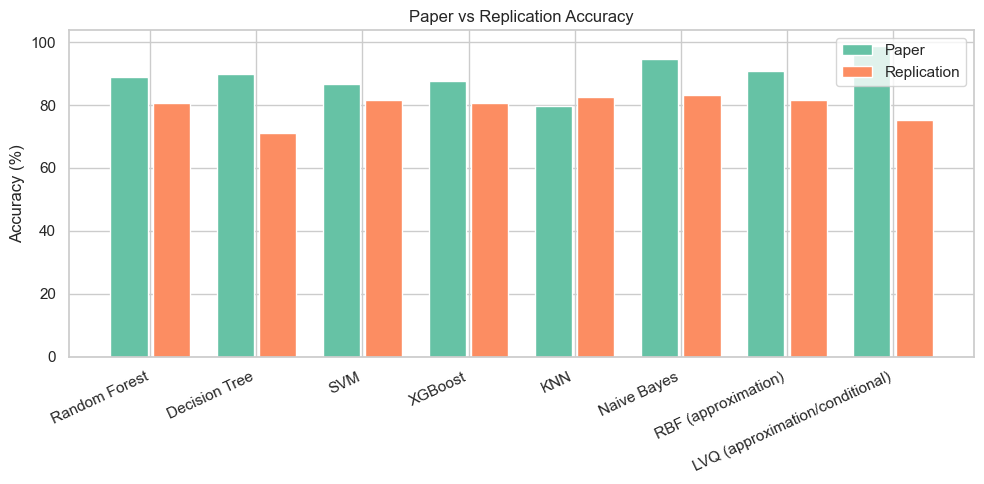

In [20]:
# Plotting for paper-vs-replication comparison
plt.figure(figsize=(10, 5))
bar_positions = np.arange(len(comparison_df))
plt.bar(bar_positions - 0.2, comparison_df["Paper Accuracy (%)"], width=0.35, label="Paper")
plt.bar(bar_positions + 0.2, comparison_df["Replication Accuracy (%)"], width=0.35, label="Replication")
plt.xticks(bar_positions, comparison_df["Model"], rotation=25, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Paper vs Replication Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

#### Discussion

Beberapa kemungkinan penyebab hasil replikasi berbeda dari paper:

- dataset paper 503 observations tidak dapat direkonstruksi secara identik
- available UCI dataset berbeda dan tidak jelas filtering/selection yang digunakan paper
- paper tidak konsisten mengenai split 70:30 vs 75:25
- random seed tidak dilaporkan
- hyperparameter sebagian besar tidak dijelaskan secara lengkap
- corrected preprocessing dilakukan setelah splitting untuk mencegah data leakage
- beberapa model seperti RBF dan LVQ memerlukan pendekatan approximation karena tidak dijelaskan secara teknis di paper

Catatan penting: replikasi yang benar dalam konteks ilmiah tidak boleh mengubah preprocessing atau hyperparameter semata-mata untuk mengejar kecocokan angka paper. Tujuan utama adalah transparansi, reproduktifitas yang jujur, dan pemahaman terhadap keterbatasan metodologis yang tidak bisa dipastikan dari publikasi.

# Assignment 3: Improvement

#### Design

**Model-Specific Feature Selection and Hyperparameter Tuning** <br>
Fokus utama Improvement: <br>

- setiap model memiliki metode feature selection yang dipilih sesuai karakter algoritma;
- jumlah fitur dipilih secara terpisah per model melalui 5-fold CV pada training set;
- hyperparameter tuning dilakukan per model setelah konfigurasi fitur terbaik model tersebut dipilih;
- test set 30% tetap dikunci sampai final evaluation.

Catatan metodologis: tuning dan feature selection tidak boleh dipaksa menghasilkan test score lebih tinggi. <br> Jika hasil tidak meningkat, interpretasinya harus ditulis apa adanya.

**Recode Structural Zeros, Drop Extreme-Missing value Features, Outer Split** <br>
`chol`/`trestbps` zeros → `NaN`. <br>
`slope`/`ca`/`thal` excluded (missing rate too extreme to impute reliably). <br>
The split happens **once**, and the same `X_train_pool` / `X_test` / `cv` are reused for every experiment (E0 through the final tuned pipeline) below.

**Model, Preprocessing, and Feature-Selection** <br>
The 8 models are the same ones used throughout Assignment 2, none are added
or swapped.<br> Scaling need and feature-selection method follow the grouping
already established: tree-based models need neither scaling nor an external
selector proxy (`feature_importances_` is native); margin/distance/custom
models need scaling, and either a linear proxy (SVM) or a filter method
(`SelectKBest`, for models with no native importance) for feature selection.


#### Load Data

In [21]:
df_a3 = df_a1.copy()
df_a3["target"] = df_a3["target"].astype(int)

In [22]:
# define features type
model_order_a3 = [
    "Random Forest",
    "Decision Tree",
    "SVM",
    "XGBoost",
    "KNN",
    "Naive Bayes",
    "RBF (approximation)",
    "LVQ (approximation/conditional)",
]

all_features_a3 = [
    col for col in df_a3.columns
    if col not in ["target", "target_binary", "source_file"]
]

print("Dataframe final: df_a3")
print("Target: target; 0 = no disease, 1 = heart disease")
print("Candidate features:", all_features_a3)
print("Models:", model_order_a3)

Dataframe final: df_a3
Target: target; 0 = no disease, 1 = heart disease
Candidate features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Models: ['Random Forest', 'Decision Tree', 'SVM', 'XGBoost', 'KNN', 'Naive Bayes', 'RBF (approximation)', 'LVQ (approximation/conditional)']


#### Import Packages

In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier

try:
    import xgboost as xgb
    XGB_AVAILABLE_A3 = True
except Exception:
    xgb = None
    XGB_AVAILABLE_A3 = False

# Installed package is sklearn_lvq and the actual class is GlvqModel.
# LVQ_AVAILABLE_A3 = False
# LVQ_CLASSIFIER_A3 = None
# try:
#     from sklearn_lvq import GlvqModel
#     LVQ_AVAILABLE_A3 = True
#     LVQ_CLASSIFIER_A3 = GlvqModel(random_state=42)
# except Exception:
#     LVQ_CLASSIFIER_A3 = None

# ============================================================
# LVQ via sklvq + patch kompatibilitas (sklvq 0.1.2 vs scikit-learn/numpy baru)
# ============================================================
LVQ_AVAILABLE_A3 = False
LVQ_CLASSIFIER_A3 = None
try:
    from sklearn.utils.validation import validate_data, check_is_fitted
    from sklearn.utils import check_array as _sklearn_check_array  # ambil LANGSUNG dari sklearn, bukan dari sklvq
    import sklvq.models._base as _sklvq_base
    from sklvq import GLVQ

    def _check_array_compat(X, *args, force_all_finite=None, **kwargs):
        if force_all_finite is not None:
            kwargs["ensure_all_finite"] = force_all_finite
        return _sklearn_check_array(X, *args, **kwargs)  # selalu panggil fungsi sklearn asli

    _sklvq_base.check_array = _check_array_compat  # aman di-assign berkali-kali, tidak pernah nunjuk ke dirinya sendiri

    class GLVQCompat(GLVQ):
        def _validate_data(self, X, y, force_all_finite=True, **kwargs):
            return validate_data(self, X, y, ensure_all_finite=force_all_finite, **kwargs)

        def predict(self, X):
            check_is_fitted(self)
            dv = self.decision_function(X)
            if self.classes_.size == 2:
                return self.classes_[(dv > 0).astype(int)]
            return self.classes_[dv.argmax(axis=1)]

        # --- FIX: tell modern scikit-learn this is a classifier ---
        def __sklearn_tags__(self):
            tags = super().__sklearn_tags__()
            tags.estimator_type = "classifier"
            return tags

    LVQ_CLASSIFIER_A3 = GLVQCompat(random_state=42)
    LVQ_AVAILABLE_A3 = True
except ImportError as e:
    print(f"sklvq tidak tersedia: {e}")
    LVQ_AVAILABLE_A3 = False

RANDOM_STATE = 42
PRIMARY_METRIC = "balanced_accuracy"

#### Outer Train-Test Split

In [24]:
X_a3 = df_a3[all_features_a3].copy()
y_a3 = df_a3["target"].astype(int).copy()

X_train_a3, X_test_a3, y_train_a3, y_test_a3 = train_test_split(
    X_a3,
    y_a3,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_a3,
    shuffle=True,
)

split_summary_a3 = pd.DataFrame([
    {
        "Dataset": "Train",
        "N": len(y_train_a3),
        "Percentage": len(y_train_a3) / len(y_a3) * 100,
        "Class 0": int((y_train_a3 == 0).sum()),
        "Class 1": int((y_train_a3 == 1).sum()),
    },
    {
        "Dataset": "Test",
        "N": len(y_test_a3),
        "Percentage": len(y_test_a3) / len(y_a3) * 100,
        "Class 0": int((y_test_a3 == 0).sum()),
        "Class 1": int((y_test_a3 == 1).sum()),
    },
])
display(split_summary_a3)

,Dataset,N,Percentage,Class 0,Class 1
0,Train,644,70.000,288,356
1,Test,276,30.000,123,153


In [25]:
X_test_a3.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
765,63.000,1.000,4.000,136.000,0.000,0.000,0.000,84.000,1.000,0.000,NaN,NaN,7.000
778,62.000,1.000,2.000,NaN,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN
825,61.000,1.000,4.000,120.000,282.000,0.000,1.000,135.000,1.000,4.000,3.000,NaN,6.000
97,60.000,0.000,4.000,150.000,258.000,0.000,2.000,157.000,0.000,2.600,2.000,2.000,7.000
482,59.000,1.000,2.000,140.000,287.000,0.000,0.000,150.000,0.000,0.000,NaN,NaN,NaN


#### Recode Structural Zeros, Re-Classify Data Type, Drop Extreme-Missing Features

In [26]:
# oldpeak = 0 is NOT recoded —> clinically valid value
# change 0 in chol and trestbps to NaN
X_train_a3["chol"] = X_train_a3["chol"].replace(0, np.nan)
X_train_a3["trestbps"] = X_train_a3["trestbps"].replace(0, np.nan)

X_test_a3["chol"] = X_test_a3["chol"].replace(0, np.nan)
X_test_a3["trestbps"] = X_test_a3["trestbps"].replace(0, np.nan)

X_test_a3.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
765,63.000,1.000,4.000,136.000,NaN,0.000,0.000,84.000,1.000,0.000,NaN,NaN,7.000
778,62.000,1.000,2.000,NaN,NaN,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN
825,61.000,1.000,4.000,120.000,282.000,0.000,1.000,135.000,1.000,4.000,3.000,NaN,6.000
97,60.000,0.000,4.000,150.000,258.000,0.000,2.000,157.000,0.000,2.600,2.000,2.000,7.000
482,59.000,1.000,2.000,140.000,287.000,0.000,0.000,150.000,0.000,0.000,NaN,NaN,NaN


In [27]:
# Define features type
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
binary_features = ["sex", "fbs", "exang"]
nominal_features = ["cp", "restecg"]

print("\n numeric:", numeric_features, 
      "\n binary:", binary_features, 
      "\n nominal:", nominal_features)


 numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] 
 binary: ['sex', 'fbs', 'exang'] 
 nominal: ['cp', 'restecg']


Dropped >30% missing: ['ca', 'thal', 'slope']
Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary features: ['sex', 'fbs', 'exang']
Nominal features: ['cp', 'restecg']


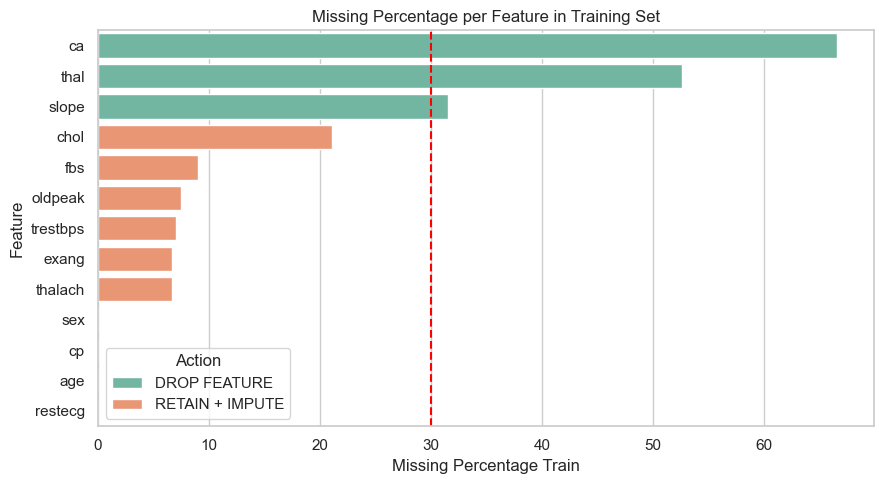

In [28]:
# check missing values rate in Training set 
missing_a3 = pd.DataFrame({
    "Feature": all_features_a3,
    "Type": ["numeric" if f in numeric_features
             else "binary" if f in binary_features
             else "nominal" if f in nominal_features
             else None
             for f in all_features_a3
            ],
    "Missing Count Train": [X_train_a3[feature].isna().sum() for feature in all_features_a3],
    "Missing Percentage Train": [X_train_a3[feature].isna().mean() * 100 for feature in all_features_a3],
})
missing_a3["Action"] = np.where(missing_a3["Missing Percentage Train"] > 30, "DROP FEATURE", "RETAIN + IMPUTE")
missing_a3 = missing_a3.sort_values("Missing Percentage Train", ascending=False)

# Drop features in Training sets with >30% missing rate
features_dropped_missing_gt30_a3 = missing_a3.loc[missing_a3["Action"] == "DROP FEATURE", "Feature"].tolist()
features_retained_a3 = missing_a3.loc[missing_a3["Action"] == "RETAIN + IMPUTE", "Feature"].tolist()

# Training sets with only features has <30% missing rate
X_train_retained_a3 = X_train_a3[features_retained_a3].copy()
X_test_retained_a3 = X_test_a3[features_retained_a3].copy()

numerical_features_a3 = [feature for feature in numeric_features if feature in features_retained_a3]
binary_features_a3 = [feature for feature in binary_features if feature in features_retained_a3]
nominal_features_a3 = [feature for feature in nominal_features if feature in features_retained_a3]

print("Dropped >30% missing:", features_dropped_missing_gt30_a3)
print("Numerical features:", numerical_features_a3)
print("Binary features:", binary_features_a3)
print('Nominal features:', nominal_features_a3)

plt.figure(figsize=(9, 5))
sns.barplot(data=missing_a3, y="Feature", x="Missing Percentage Train", hue="Action", dodge=False)
plt.axvline(30, color="red", linestyle="--", label="30% threshold")
plt.title("Missing Percentage per Feature in Training Set")
plt.tight_layout()
plt.show()

#### K-Fold Cross Validation

Cross-validation dilakukan hanya pada training set 70%, bukan pada seluruh dataset. Test set 30% dikunci sejak awal dan hanya digunakan pada final evaluation.

Konfigurasi CV: <br>
- `n_splits` = 5
- `shuffle` = True
- `random_state` = 42

Pada setiap fold, pipeline melakukan fit imputer, scaler, feature selector, dan model hanya pada training fold. Validation fold hanya ditransform dan dievaluasi. <br> Dengan cara ini, validation fold dan test set tidak bocor ke proses preprocessing, seleksi fitur, atau tuning.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

#### Model-Specific Preprocessing

In [30]:
# Estimators
def make_onehot_encoder_a3r():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    
def make_estimators_a3():
    estimators = {
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        "XGBoost": None,
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Naive Bayes": GaussianNB(),
        "RBF (approximation)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        "LVQ (approximation/conditional)": None,
    }
    if XGB_AVAILABLE_A3:
        estimators["XGBoost"] = xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if LVQ_AVAILABLE_A3:
        estimators["LVQ (approximation/conditional)"] = LVQ_CLASSIFIER_A3
    return estimators

estimators_a3 = make_estimators_a3()
available_models_a3 = {name: est for name, est in estimators_a3.items() if est is not None}
skipped_models_a3 = {name: "Model/package tidak tersedia" for name, est in estimators_a3.items() if est is None}

print("Available models:", list(available_models_a3))
print("Skipped models:", skipped_models_a3)

Available models: ['Random Forest', 'Decision Tree', 'SVM', 'XGBoost', 'KNN', 'Naive Bayes', 'RBF (approximation)', 'LVQ (approximation/conditional)']
Skipped models: {}


In [31]:
# Scaling
scaling_table_a3 = pd.DataFrame([
    {"Model": "Random Forest", "Scaling": "No", "Reason": "Tree ensemble uses threshold splits."},
    {"Model": "Decision Tree", "Scaling": "No", "Reason": "Tree uses threshold splits."},
    {"Model": "SVM", "Scaling": "Yes", "Reason": "Kernel distance/similarity is magnitude-sensitive."},
    {"Model": "XGBoost", "Scaling": "No", "Reason": "Boosted trees use threshold splits."},
    {"Model": "KNN", "Scaling": "Yes", "Reason": "Neighbor distance is magnitude-sensitive."},
    {"Model": "Naive Bayes", "Scaling": "No", "Reason": "GaussianNB does not require distance-based scaling."},
    {"Model": "RBF (approximation)", "Scaling": "Yes", "Reason": "RBF distance/similarity is magnitude-sensitive."},
    {"Model": "LVQ (approximation/conditional)", "Scaling": "Yes", "Reason": "Prototype distances are magnitude-sensitive."},
])
scale_sensitive_models_a3 = set(scaling_table_a3.loc[scaling_table_a3["Scaling"] == "Yes", "Model"])

display(scaling_table_a3)

,Model,Scaling,Reason
0,Random Forest,No,Tree ensemble uses threshold splits.
1,Decision Tree,No,Tree uses threshold splits.
2,SVM,Yes,Kernel distance/similarity is magnitude-sensit...
3,XGBoost,No,Boosted trees use threshold splits.
4,KNN,Yes,Neighbor distance is magnitude-sensitive.
5,Naive Bayes,No,GaussianNB does not require distance-based sca...
6,RBF (approximation),Yes,RBF distance/similarity is magnitude-sensitive.
7,LVQ (approximation/conditional),Yes,Prototype distances are magnitude-sensitive.


#### Model-Specific Feature Selection

Feature selection pada Assignment 3 tidak dibuat sebagai satu subset fitur universal. Setiap model memilih fitur secara terpisah karena mekanisme algoritmanya berbeda.

| Model | Metode feature selection | Alasan |
|---|---|---|
| Random Forest | `SelectFromModel(RandomForestClassifier)` | Random Forest memiliki feature importance bawaan dari ensemble tree. |
| Decision Tree | `RFE(DecisionTreeClassifier)` | Decision Tree memiliki importance; RFE menghapus fitur secara bertahap berdasarkan kontribusi model. |
| SVM | `RFE(LinearSVC)` | Final model memakai RBF SVM, tetapi RBF tidak mudah memberi ranking fitur langsung; LinearSVC dipakai sebagai proxy margin-based. |
| XGBoost | `SelectFromModel(XGBClassifier)` | XGBoost adalah boosted tree dan memiliki feature importance bawaan. |
| KNN | `SelectKBest(mutual information)` | KNN tidak memiliki feature importance bawaan; mutual information menilai hubungan fitur dengan target. |
| Naive Bayes | `SelectKBest(mutual information)` | Naive Bayes tidak memiliki feature importance bawaan yang stabil. |
| RBF approximation | `RFE(LinearSVC)` | LinearSVC dipakai sebagai proxy untuk ranking fitur sebelum final RBF model. |
| LVQ | `SelectKBest(mutual information)` | LVQ berbasis prototype-distance dan tidak menyediakan importance bawaan yang kompatibel dengan pipeline sklearn. |

Fitur yang dilaporkan ada dua bentuk:

- `Selected original features`: nama fitur asli sebelum encoding, misalnya `age`, `chol`, `cp`, `exang`.
- `Selected transformed features`: fitur setelah preprocessing, terutama setelah one-hot encoding, misalnya `cat__cp_4.0` atau `cat__sex_1.0`.

**Pemilihan Jumlah Fitur** <br>

`k` adalah jumlah fitur hasil preprocessing yang dipilih oleh feature selection. Karena binary/nominal features diubah dengan one-hot encoding, 10 fitur asli dapat menjadi 18 transformed features.<br> Untuk setiap model dan setiap nilai `k`, notebook menjalankan pipeline dengan Stratified 5-Fold CV pada training set, lalu mencatat mean dan standard deviation `balanced_accuracy`. Nilai `k` terbaik dipilih berdasarkan mean CV tertinggi dengan mempertimbangkan variasi antar-fold.<br> Tabel fitur final tiap model dapat dilihat pada `per_model_summary_a3`, terutama kolom `Selected original features` dan `Selected transformed features`.

In [32]:
# Feature Selection
fs_design_a3 = pd.DataFrame([
    {"Model": "Random Forest", "Feature Selection": "SelectFromModel(RandomForest)", "Reason": "Uses RF impurity-based ensemble importance."},
    {"Model": "Decision Tree", "Feature Selection": "RFE(DecisionTree)", "Reason": "Recursively removes features using decision-tree importance."},
    {"Model": "SVM", "Feature Selection": "RFE(LinearSVC)", "Reason": "Uses linear SVM weights as a stable proxy before final RBF SVM."},
    {"Model": "XGBoost", "Feature Selection": "SelectFromModel(XGBoost)", "Reason": "Uses boosted-tree feature importance."},
    {"Model": "KNN", "Feature Selection": "SelectKBest(mutual information)", "Reason": "KNN has no native importance; MI ranks variables before distance model."},
    {"Model": "Naive Bayes", "Feature Selection": "SelectKBest(mutual information)", "Reason": "Naive Bayes has no robust native importance; MI captures target association."},
    {"Model": "RBF (approximation)", "Feature Selection": "RFE(LinearSVC)", "Reason": "Uses margin-based ranking before final RBF-kernel approximation."},
    {"Model": "LVQ (approximation/conditional)", "Feature Selection": "SelectKBest(mutual information)", "Reason": "LVQ is prototype-based and lacks sklearn-compatible importance."},
])
display(fs_design_a3)

,Model,Feature Selection,Reason
0,Random Forest,SelectFromModel(RandomForest),Uses RF impurity-based ensemble importance.
1,Decision Tree,RFE(DecisionTree),Recursively removes features using decision-tr...
2,SVM,RFE(LinearSVC),Uses linear SVM weights as a stable proxy befo...
3,XGBoost,SelectFromModel(XGBoost),Uses boosted-tree feature importance.
4,KNN,SelectKBest(mutual information),KNN has no native importance; MI ranks variabl...
5,Naive Bayes,SelectKBest(mutual information),Naive Bayes has no robust native importance; M...
6,RBF (approximation),RFE(LinearSVC),Uses margin-based ranking before final RBF-ker...
7,LVQ (approximation/conditional),SelectKBest(mutual information),LVQ is prototype-based and lacks sklearn-compa...


In [33]:
# Pipeline Functions

# Build Preprocessor Pipelines
# Define pipeline steps for Prepocessing of each model (missing values imputation, scaling, one-hot encoding).
def build_preprocessor_a3(needs_scaling, numeric_impute_strategy="median"):
    numeric_steps = [("imputer", SimpleImputer(strategy=numeric_impute_strategy))]
    if needs_scaling:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(numeric_steps)

    binary_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    transformers = []
    if numerical_features_a3:
        transformers.append(("num", numeric_pipeline, numerical_features_a3))
    if binary_features_a3:
        transformers.append(("bin", binary_pipeline, binary_features_a3))
    if nominal_features_a3:
        transformers.append(("nom", nominal_pipeline, nominal_features_a3))

    return ColumnTransformer(transformers)

# Get features name from preprocessing result
def transformed_feature_names_a3(preprocessor):
    try:
        return preprocessor.get_feature_names_out().tolist()
    except Exception:
        sample = preprocessor.transform(X_train_retained_a3.head(2))
        return [f"feature_{idx}" for idx in range(sample.shape[1])]

# Function untuk menentukan batas atas k di selector_for_model_a3
def transformed_feature_count_a3(model_name):
    pp = build_preprocessor_a3(model_name in scale_sensitive_models_a3)
    pp.fit(X_train_retained_a3, y_train_a3)
    return len(transformed_feature_names_a3(pp))

# Fungsi skor untuk 'SelectKBest'
def mutual_info_score_a3(X, y):
    return mutual_info_classif(X, y, random_state=RANDOM_STATE)

# Feature Selection Pipelines
# Define pipeline steps for Feature Selection of each model, retain the 'k' best features.
def selector_for_model_a3(model_name, k):
    if model_name == "Random Forest": return SelectFromModel(RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
                                                             threshold=-np.inf,
                                                             max_features=k,
                                                            )
    if model_name == "Decision Tree": return RFE(DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
                                                 n_features_to_select=k,
                                                 step=1,
                                                )
    if model_name == "SVM": return RFE(LinearSVC(C=0.5, dual=False, max_iter=10000, random_state=RANDOM_STATE),
                                       n_features_to_select=k,
                                       step=1,
                                       )
    if model_name == "XGBoost": return SelectFromModel(xgb.XGBClassifier(objective="binary:logistic",
                                                                         eval_metric="logloss",
                                                                         n_estimators=120,
                                                                         max_depth=3,
                                                                         learning_rate=0.05,
                                                                         random_state=RANDOM_STATE,
                                                                         n_jobs=-1,),
                                                        threshold=-np.inf,
                                                        max_features=k,)
    if model_name == "KNN": return SelectKBest(score_func=mutual_info_score_a3, k=k)
    if model_name == "Naive Bayes": return SelectKBest(score_func=mutual_info_score_a3, k=k)
    if model_name == "RBF (approximation)": return RFE(LinearSVC(C=0.5, dual=False, max_iter=10000, random_state=RANDOM_STATE),
                                                      n_features_to_select=k,
                                                      step=1,)
    if model_name == "LVQ (approximation/conditional)": return SelectKBest(score_func=mutual_info_score_a3, k=k)
    raise ValueError(f"Unknown model: {model_name}")

# Build All Pipeline
def build_pipeline_a3(model_name, estimator, selector=None):
    steps = [("preprocessor", build_preprocessor_a3(model_name in scale_sensitive_models_a3))]
    if selector is not None:
        steps.append(("feature_selection", selector))
    steps.append(("model", estimator))
    return Pipeline(steps)

In [34]:
# Evaluation Metrics
def specificity_score_a3r(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

scoring_a3 = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "specificity": make_scorer(specificity_score_a3r),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

In [35]:
# Summary
def summarize_cv_a3(cv_result, model_name, experiment):
    row = {"Model": model_name, "Experiment": experiment}
    for metric in scoring_a3:
        key = f"test_{metric}"
        if key in cv_result:
            row[f"{metric}_mean"] = np.nanmean(cv_result[key])
            row[f"{metric}_std"] = np.nanstd(cv_result[key])
    return row

In [36]:
# Function to generate candidate k values (number of features) for feature-selection tuning —> exhaustive when few features, sparse fixed grid when many
def k_grid_a3(n_features):
    if n_features <= 12:
        return list(range(3, n_features + 1))
    return sorted(set([3, 4, 5, 6, 8, 10, 12, 15, n_features]))

#### E0: Baseline Audit

In [37]:
# For newly run results_df we need to run this
# metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1", "Balanced Accuracy"]

# a2_baseline = (
#     results_df
#     .drop(columns=["Confusion Matrix", "Status"])
#     .assign(**{"Balanced Accuracy": lambda d: (d["Recall"] + d["Specificity"]) / 2})
#     .assign(Assignment="A2")
# )
# a2_baseline[metric_cols] = a2_baseline[metric_cols].round(3)
# a2_baseline = a2_baseline[["Model", "Assignment"] + metric_cols]
# display(a2_baseline)

In [38]:
# But We Already run Assignment 2
# Do not rerun Assignment #2 or replace these values with Assignment #3 results.
reported_assignment2_baseline_a3 = pd.DataFrame([
    {"Model": "Random Forest", "A2 Accuracy": 0.808, "A2 Precision": 0.829, "A2 Recall": 0.824, "A2 Specificity": 0.789, "A2 F1": 0.826, "A2 Balanced Accuracy": 0.806, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
    {"Model": "Decision Tree", "A2 Accuracy": 0.710, "A2 Precision": 0.735, "A2 Recall": 0.745, "A2 Specificity": 0.667, "A2 F1": 0.740, "A2 Balanced Accuracy": 0.706, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
    {"Model": "SVM", "A2 Accuracy": 0.815, "A2 Precision": 0.827, "A2 Recall": 0.843, "A2 Specificity": 0.780, "A2 F1": 0.835, "A2 Balanced Accuracy": 0.812, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
    {"Model": "XGBoost", "A2 Accuracy": 0.808, "A2 Precision": 0.825, "A2 Recall": 0.830, "A2 Specificity": 0.780, "A2 F1": 0.827, "A2 Balanced Accuracy": 0.805, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
    {"Model": "KNN", "A2 Accuracy": 0.826, "A2 Precision": 0.839, "A2 Recall": 0.850, "A2 Specificity": 0.797, "A2 F1": 0.844, "A2 Balanced Accuracy": 0.823, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
    {"Model": "Naive Bayes", "A2 Accuracy": 0.833, "A2 Precision": 0.869, "A2 Recall": 0.824, "A2 Specificity": 0.846, "A2 F1": 0.846, "A2 Balanced Accuracy": 0.835, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
    {"Model": "RBF (approximation)", "A2 Accuracy": 0.815, "A2 Precision": 0.827, "A2 Recall": 0.843, "A2 Specificity": 0.780, "A2 F1": 0.835, "A2 Balanced Accuracy": 0.812, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
    {"Model": "LVQ (approximation/conditional)", "A2 Accuracy": 0.764, "A2 Precision": 0.789, "A2 Recall": 0.784, "A2 Specificity": 0.740, "A2 F1": 0.787, "A2 Balanced Accuracy": 0.762, "A2 Source": "Assignment3_Improved_Pipeline.ipynb"},
])
display(reported_assignment2_baseline_a3)

,Model,A2 Accuracy,A2 Precision,A2 Recall,A2 Specificity,A2 F1,A2 Balanced Accuracy,A2 Source
0,Random Forest,0.808,0.829,0.824,0.789,0.826,0.806,Assignment3_Improved_Pipeline.ipynb
1,Decision Tree,0.710,0.735,0.745,0.667,0.740,0.706,Assignment3_Improved_Pipeline.ipynb
2,SVM,0.815,0.827,0.843,0.780,0.835,0.812,Assignment3_Improved_Pipeline.ipynb
3,XGBoost,0.808,0.825,0.830,0.780,0.827,0.805,Assignment3_Improved_Pipeline.ipynb
4,KNN,0.826,0.839,0.850,0.797,0.844,0.823,Assignment3_Improved_Pipeline.ipynb
5,Naive Bayes,0.833,0.869,0.824,0.846,0.846,0.835,Assignment3_Improved_Pipeline.ipynb
6,RBF (approximation),0.815,0.827,0.843,0.780,0.835,0.812,Assignment3_Improved_Pipeline.ipynb
7,LVQ (approximation/conditional),0.764,0.789,0.784,0.740,0.787,0.762,Assignment3_Improved_Pipeline.ipynb


In [39]:
a2_baseline_a3 = reported_assignment2_baseline_a3.copy()
a2_features_a3 = paper_features if "paper_features" in globals() else "Reported Assignment #2 features"
a2_audit_a3 = pd.DataFrame({
    "Model": model_order_a3,
    "Assignment #2 preprocessing": [
        "Mean numeric imputation; most-frequent categorical imputation + one-hot; model-specific scaling"
        for _ in model_order_a3
    ],
    "Assignment #2 features": [a2_features_a3 for _ in model_order_a3],
}).merge(a2_baseline_a3, on="Model", how="left")

print("E0 loaded from Assignment 2 results:")
display(a2_audit_a3)

E0 loaded from Assignment 2 results:


,Model,Assignment #2 preprocessing,Assignment #2 features,A2 Accuracy,A2 Precision,A2 Recall,A2 Specificity,A2 F1,A2 Balanced Accuracy,A2 Source
0,Random Forest,Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.808,0.829,0.824,0.789,0.826,0.806,Assignment3_Improved_Pipeline.ipynb
1,Decision Tree,Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.710,0.735,0.745,0.667,0.740,0.706,Assignment3_Improved_Pipeline.ipynb
2,SVM,Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.815,0.827,0.843,0.780,0.835,0.812,Assignment3_Improved_Pipeline.ipynb
3,XGBoost,Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.808,0.825,0.830,0.780,0.827,0.805,Assignment3_Improved_Pipeline.ipynb
4,KNN,Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.826,0.839,0.850,0.797,0.844,0.823,Assignment3_Improved_Pipeline.ipynb
5,Naive Bayes,Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.833,0.869,0.824,0.846,0.846,0.835,Assignment3_Improved_Pipeline.ipynb
6,RBF (approximation),Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.815,0.827,0.843,0.780,0.835,0.812,Assignment3_Improved_Pipeline.ipynb
7,LVQ (approximation/conditional),Mean numeric imputation; most-frequent categor...,"[sex, age, cp, trestbps, chol, fbs, restecg, t...",0.764,0.789,0.784,0.740,0.787,0.762,Assignment3_Improved_Pipeline.ipynb


#### E1: Preprocessing-Only Baseline on Training CV

Implementation:<br>
- Preprocessing-Only (Missing Values Imputation, Scaling, etc)
- 5-Fold Cross Validation
- No Feature Selection
- No Hyperparameter Tuning

In [40]:
e1_rows_a3 = []
for model_name, estimator in available_models_a3.items():
    pipe = build_pipeline_a3(model_name, clone(estimator), selector=None)
    cv_result = cross_validate(
        pipe,
        X_train_retained_a3,
        y_train_a3,
        cv=cv,
        scoring=scoring_a3,
        n_jobs=-1,
        error_score=np.nan,
    )
    e1_rows_a3.append(summarize_cv_a3(cv_result, model_name, "E1"))

e1_results_a3 = pd.DataFrame(e1_rows_a3).sort_values("balanced_accuracy_mean", ascending=False)
display(e1_results_a3)

,Model,Experiment,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,specificity_mean,specificity_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Random Forest,E1,0.798,0.018,0.793,0.018,0.801,0.021,0.845,0.032,0.740,0.035,0.822,0.018,0.851,0.026
5,Naive Bayes,E1,0.793,0.030,0.791,0.030,0.811,0.028,0.817,0.035,0.764,0.040,0.814,0.028,0.865,0.024
2,SVM,E1,0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030
6,RBF (approximation),E1,0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030
3,XGBoost,E1,0.790,0.024,0.785,0.025,0.797,0.027,0.834,0.021,0.736,0.038,0.815,0.021,0.832,0.028
4,KNN,E1,0.770,0.018,0.762,0.018,0.767,0.016,0.840,0.026,0.684,0.028,0.801,0.017,0.822,0.024
1,Decision Tree,E1,0.710,0.029,0.707,0.031,0.741,0.036,0.733,0.037,0.681,0.060,0.736,0.027,0.707,0.031
7,LVQ (approximation/conditional),E1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### E2: Model-Specific Feature Selection and Number of Features

Implementation:<br>
- Preprocessing (Missing Values Imputation, Scaling, etc)
- 5-Fold Cross Validation
- Feature Selection based on Model
- No Hyperparameter Tuning

Random Forest: transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]
Decision Tree: transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]
SVM: transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]
XGBoost: transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]
KNN: transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]
Naive Bayes: transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]
RBF (approximation): transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]
LVQ (approximation/conditional): transformed features before FS=15; k grid=[3, 4, 5, 6, 8, 10, 12, 15]


,Model,k,cv_mean,cv_std,transformed_before,fs_method
0,Decision Tree,15,0.707,0.031,15,RFE(DecisionTree)
1,KNN,8,0.763,0.015,15,SelectKBest(mutual information)
2,LVQ (approximation/conditional),3,NaN,NaN,15,SelectKBest(mutual information)
3,Naive Bayes,15,0.791,0.030,15,SelectKBest(mutual information)
4,RBF (approximation),15,0.786,0.022,15,RFE(LinearSVC)
5,Random Forest,12,0.797,0.032,15,SelectFromModel(RandomForest)
6,SVM,15,0.786,0.022,15,RFE(LinearSVC)
7,XGBoost,12,0.792,0.030,15,SelectFromModel(XGBoost)


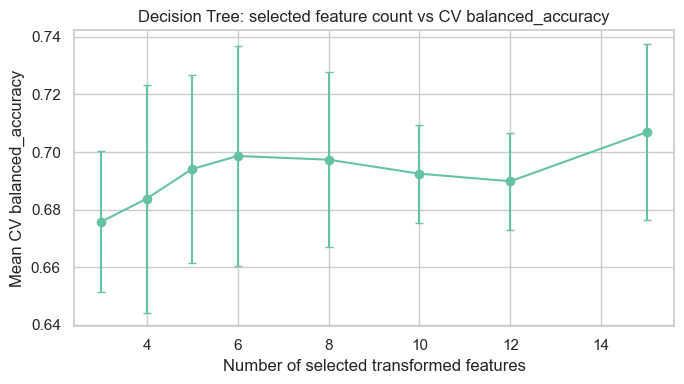

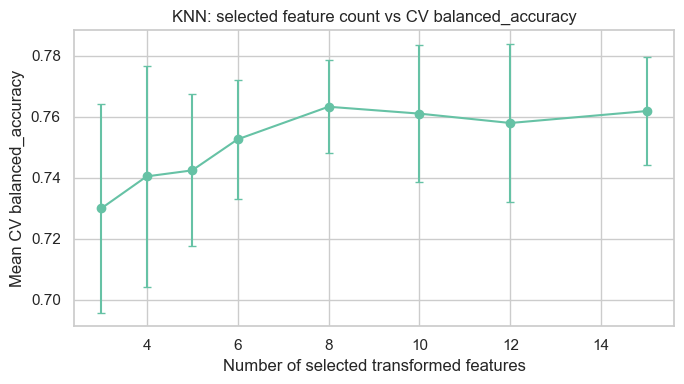

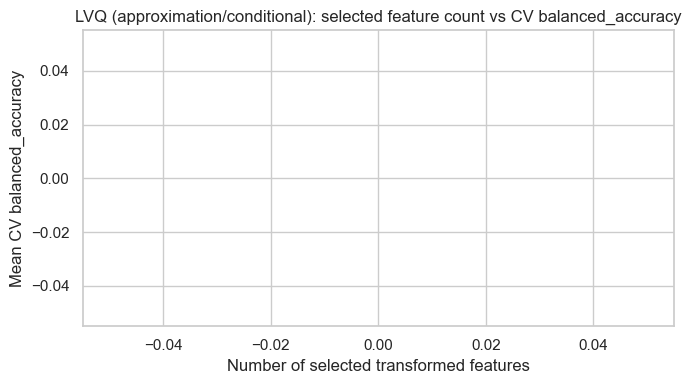

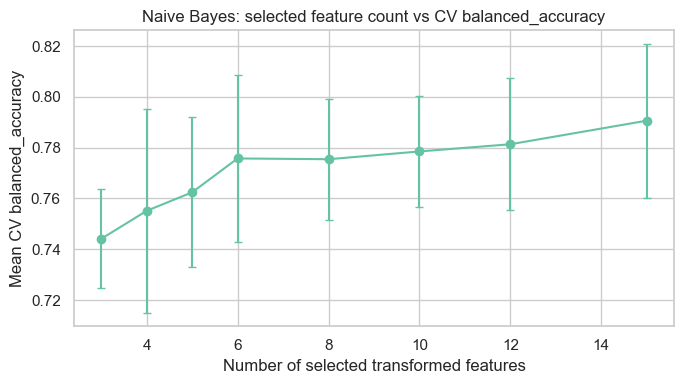

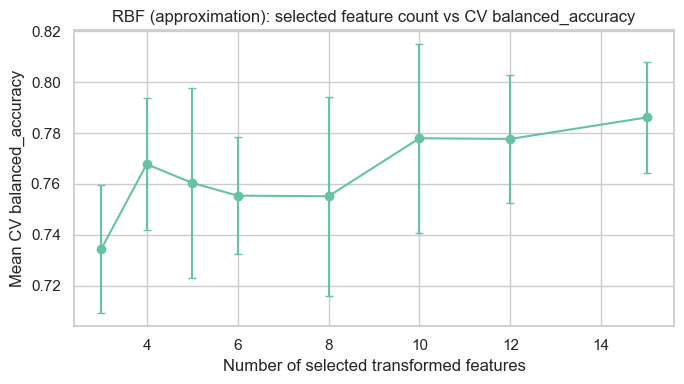

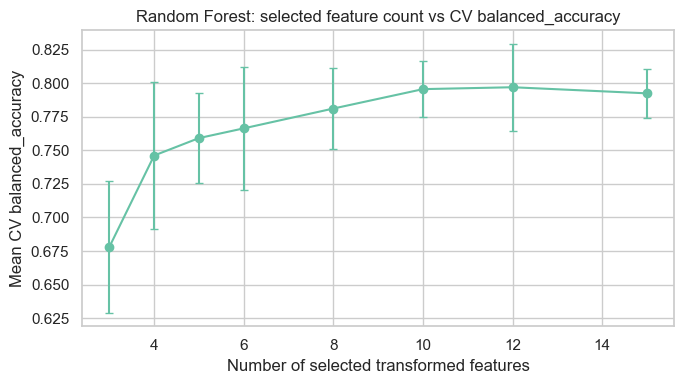

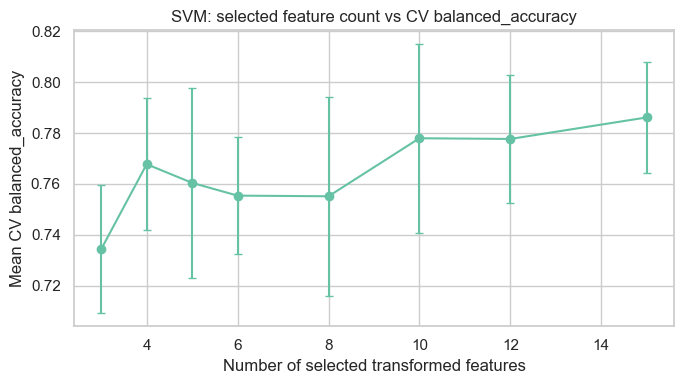

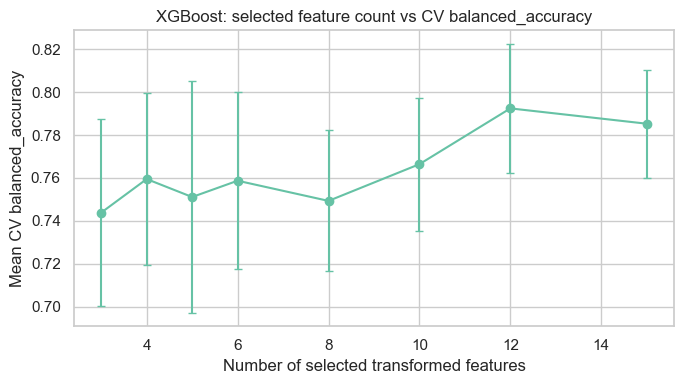

In [41]:
# Part 1 = pencarian (search). 
# Implementasi: Untuk tiap model, coba semua nilai k di grid, masing-masing cuma di-CV pada satu metrik (PRIMARY_METRIC, kemungkinan balanced_accuracy) supaya cepat. 
# Tujuannya: cari k terbaik per model, lalu simpan di best_fs_config_a3. 
# Output: best_k_table_a3 dan grafik k-vs-performance
fs_search_rows_a3 = []
best_fs_config_a3 = {}

for model_name, estimator in available_models_a3.items():
    n_features = transformed_feature_count_a3(model_name)
    k_values = k_grid_a3(n_features)
    fs_method = fs_design_a3.loc[fs_design_a3["Model"] == model_name, "Feature Selection"].iloc[0]
    print(f"{model_name}: transformed features before FS={n_features}; k grid={k_values}")
    for k in k_values:
        selector = selector_for_model_a3(model_name, k)
        pipe = build_pipeline_a3(model_name, clone(estimator), selector=selector)
        cv_result = cross_validate(
            pipe,
            X_train_retained_a3,
            y_train_a3,
            cv=cv,
            scoring={PRIMARY_METRIC: PRIMARY_METRIC},
            n_jobs=-1,
            error_score=np.nan,
        )
        scores = cv_result[f"test_{PRIMARY_METRIC}"]
        fs_search_rows_a3.append({
            "Model": model_name,
            "FS method": fs_method,
            "Transformed features before FS": n_features,
            "k tested": k,
            "CV mean": np.nanmean(scores),
            "CV std": np.nanstd(scores),
        })

fs_search_results_a3 = pd.DataFrame(fs_search_rows_a3)
for model_name, group in fs_search_results_a3.groupby("Model"):
    ranked = group.sort_values(["CV mean", "CV std", "k tested"], ascending=[False, True, True])
    best = ranked.iloc[0]
    best_fs_config_a3[model_name] = {
        "k": int(best["k tested"]),
        "cv_mean": float(best["CV mean"]),
        "cv_std": float(best["CV std"]),
        "transformed_before": int(best["Transformed features before FS"]),
        "fs_method": best["FS method"],
    }

best_k_table_a3 = pd.DataFrame([{"Model": model, **cfg} for model, cfg in best_fs_config_a3.items()])
display(best_k_table_a3)

for model_name, group in fs_search_results_a3.groupby("Model"):
    plt.figure(figsize=(7, 4))
    plt.errorbar(group["k tested"], group["CV mean"], yerr=group["CV std"], marker="o", capsize=3)
    plt.title(f"{model_name}: selected feature count vs CV {PRIMARY_METRIC}")
    plt.xlabel("Number of selected transformed features")
    plt.ylabel(f"Mean CV {PRIMARY_METRIC}")
    plt.tight_layout()
    plt.show()

In [42]:
# Part 2 => evaluasi final (E2) pakai k yang sudah dipilih. 
# Implementasi: Untuk tiap model, ambil k terbaik dari Part 1, lalu jalankan ulang CV, Fit pipeline penuh di training set untuk feature selection, 

def selected_feature_names_a3(fitted_pipeline):
    pp = fitted_pipeline.named_steps["preprocessor"]
    names = np.array(transformed_feature_names_a3(pp))
    selector = fitted_pipeline.named_steps.get("feature_selection")
    if selector is not None and hasattr(selector, "get_support"):
        return names[selector.get_support()].tolist()
    return names.tolist()

def to_original_feature_names_a3(transformed_names):
    originals = []
    for name in transformed_names:
        clean = name.split("__", 1)[-1]
        match = None
        for feature in features_retained_a3:
            if clean == feature or clean.startswith(f"{feature}_"):
                match = feature
                break
        originals.append(match or clean)
    return sorted(set(originals))

def transformed_to_original_mapping_a3(transformed_names):
    return {
        name: to_original_feature_names_a3([name])[0]
        for name in transformed_names
    }

e2_rows_a3 = []
selected_transformed_by_model_a3 = {}
selected_original_by_model_a3 = {}
transformed_to_original_by_model_a3 = {}

for model_name, estimator in available_models_a3.items():
    k = best_fs_config_a3[model_name]["k"]
    selector = selector_for_model_a3(model_name, k)
    pipe = build_pipeline_a3(model_name, clone(estimator), selector=selector)
    cv_result = cross_validate(
        pipe,
        X_train_retained_a3,
        y_train_a3,
        cv=cv,
        scoring=scoring_a3,
        n_jobs=-1,
        error_score=np.nan,
    )
    fitted = clone(pipe).fit(X_train_retained_a3, y_train_a3)
    all_transformed = transformed_feature_names_a3(fitted.named_steps["preprocessor"])
    selected_transformed = selected_feature_names_a3(fitted)
    selected_original = to_original_feature_names_a3(selected_transformed)
    selected_transformed_by_model_a3[model_name] = selected_transformed
    selected_original_by_model_a3[model_name] = selected_original
    transformed_to_original_by_model_a3[model_name] = transformed_to_original_mapping_a3(all_transformed)

    row = summarize_cv_a3(cv_result, model_name, "E2 model-specific FS")
    row["FS method"] = best_fs_config_a3[model_name]["fs_method"]
    row["Transformed features before FS"] = len(all_transformed)
    row["k tested"] = sorted(fs_search_results_a3.loc[fs_search_results_a3["Model"] == model_name, "k tested"].tolist())
    row["Selected transformed features"] = selected_transformed
    row["Selected original clinical features"] = selected_original
    row["Number selected transformed features"] = len(selected_transformed)
    row["Number selected original clinical features"] = len(selected_original)
    e2_rows_a3.append(row)
    
e2_results_a3 = pd.DataFrame(e2_rows_a3)
display(e2_results_a3)

,Model,Experiment,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,specificity_mean,specificity_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,FS method,Transformed features before FS,k tested,Selected transformed features,Selected original clinical features,Number selected transformed features,Number selected original clinical features
0,Random Forest,E2 model-specific FS,0.803,0.031,0.797,0.032,0.804,0.033,0.851,0.027,0.743,0.047,0.827,0.027,0.854,0.025,SelectFromModel(RandomForest),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ...",12,10
1,Decision Tree,E2 model-specific FS,0.710,0.029,0.707,0.031,0.741,0.036,0.733,0.037,0.681,0.060,0.736,0.027,0.707,0.031,RFE(DecisionTree),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ...",15,10
2,SVM,E2 model-specific FS,0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030,RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ...",15,10
3,XGBoost,E2 model-specific FS,0.797,0.030,0.792,0.030,0.806,0.026,0.831,0.033,0.754,0.033,0.819,0.028,0.837,0.026,SelectFromModel(XGBoost),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, num__chol, num__thalach, num__oldpe...","[age, chol, cp, exang, fbs, oldpeak, restecg, ...",12,9
4,KNN,E2 model-specific FS,0.770,0.016,0.763,0.015,0.772,0.015,0.829,0.028,0.698,0.024,0.799,0.016,0.816,0.015,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, num__chol, num__thalach, num__oldpe...","[age, chol, cp, exang, oldpeak, restecg, thalach]",8,7
5,Naive Bayes,E2 model-specific FS,0.793,0.030,0.791,0.030,0.811,0.028,0.817,0.035,0.764,0.040,0.814,0.028,0.865,0.024,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ...",15,10
6,RBF (approximation),E2 model-specific FS,0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030,RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ...",15,10
7,LVQ (approximation/conditional),E2 model-specific FS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[num__age, bin__exang, nom__cp_2.0]","[age, cp, exang]",3,3


In [43]:
#  Compare E1 & E2
e2_summary_a3 = e2_results_a3.merge(
    e1_results_a3[["Model", "balanced_accuracy_mean", "balanced_accuracy_std"]].rename(columns={
        "balanced_accuracy_mean": "E1 CV Mean",
        "balanced_accuracy_std": "E1 CV Std",
    }),
    on="Model",
    how="left",
)
e2_summary_a3["E2 CV Mean"] = e2_summary_a3["balanced_accuracy_mean"]
e2_summary_a3["E2 CV Std"] = e2_summary_a3["balanced_accuracy_std"]
e2_summary_a3["Delta FS (E2-E1)"] = e2_summary_a3["E2 CV Mean"] - e2_summary_a3["E1 CV Mean"]
e2_summary_a3["FS Retained?"] = e2_summary_a3["Delta FS (E2-E1)"] > e2_summary_a3["E1 CV Std"].fillna(0)
e2_summary_a3["Interpretation"] = np.where(
    e2_summary_a3["FS Retained?"],
    "RETAIN: gain exceeds E1 fold variability",
    "REJECT: no meaningful gain over E1",
)

display(e2_summary_a3[[
    "Model",
    "FS method",
    "Transformed features before FS",
    "k tested",
    "Number selected transformed features",
    "Selected original clinical features",
    "E1 CV Mean",
    "E2 CV Mean",
    "Delta FS (E2-E1)",
    "FS Retained?",
    "Interpretation",
]])

,Model,FS method,Transformed features before FS,k tested,Number selected transformed features,Selected original clinical features,E1 CV Mean,E2 CV Mean,Delta FS (E2-E1),FS Retained?,Interpretation
0,Random Forest,SelectFromModel(RandomForest),15,"[3, 4, 5, 6, 8, 10, 12, 15]",12,"[age, chol, cp, exang, fbs, oldpeak, restecg, ...",0.793,0.797,0.005,False,REJECT: no meaningful gain over E1
1,Decision Tree,RFE(DecisionTree),15,"[3, 4, 5, 6, 8, 10, 12, 15]",15,"[age, chol, cp, exang, fbs, oldpeak, restecg, ...",0.707,0.707,0.000,False,REJECT: no meaningful gain over E1
2,SVM,RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]",15,"[age, chol, cp, exang, fbs, oldpeak, restecg, ...",0.786,0.786,0.000,False,REJECT: no meaningful gain over E1
3,XGBoost,SelectFromModel(XGBoost),15,"[3, 4, 5, 6, 8, 10, 12, 15]",12,"[age, chol, cp, exang, fbs, oldpeak, restecg, ...",0.785,0.792,0.007,False,REJECT: no meaningful gain over E1
4,KNN,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]",8,"[age, chol, cp, exang, oldpeak, restecg, thalach]",0.762,0.763,0.001,False,REJECT: no meaningful gain over E1
5,Naive Bayes,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]",15,"[age, chol, cp, exang, fbs, oldpeak, restecg, ...",0.791,0.791,0.000,False,REJECT: no meaningful gain over E1
6,RBF (approximation),RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]",15,"[age, chol, cp, exang, fbs, oldpeak, restecg, ...",0.786,0.786,0.000,False,REJECT: no meaningful gain over E1
7,LVQ (approximation/conditional),SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]",3,"[age, cp, exang]",NaN,NaN,NaN,False,REJECT: no meaningful gain over E1


#### E3: Model-Specific Hyperparameter Tuning

Implementasi Hyperparameter Tuning per Model:<br>
Setelah jumlah fitur terbaik dipilih untuk setiap model, hyperparameter tuning dilakukan secara terpisah per model menggunakan `GridSearchCV` dan Stratified 5-Fold CV pada training set.<br> Pipeline yang dituning tetap berisi preprocessing dan feature selection, sehingga konfigurasi terbaik dipilih tanpa menggunakan test set.<br>
Hyperparameter tuning dilakukan **setelah** keputusan feature selection selesai. E2 tetap dilaporkan sebagai eksperimen feature selection, tetapi tidak otomatis dipakai sebagai pipeline final.<br>

- Jika kenaikan E2 terhadap E1 lebih besar daripada variasi fold E1, feature selection dipertahankan dan E3 dimulai dari E2.
- Jika tidak, feature selection ditolak untuk pipeline final dan E3 dimulai dari E1 tanpa selector.

Dengan demikian, `E3 CV Mean` selalu berasal dari konfigurasi yang benar-benar masuk tuning, sedangkan `E2 CV Mean` tetap menyimpan hasil eksperimen FS yang sebenarnya. <br> Tuning memakai `scoring="balanced_accuracy"`, Stratified 5-Fold CV yang sama, dan training set saja.

In [44]:
def param_grid_a3(model_name):
    if model_name == "Random Forest":
        return {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 5, 10, 15],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": [None, "balanced"],
        }
    if model_name == "Decision Tree":
        return {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [2, 3, 5, 8, None],
            "model__min_samples_leaf": [1, 3, 5, 10],
            "model__class_weight": [None, "balanced"],
        }
    if model_name == "SVM":
        return {
            "model__C": [0.1, 1, 10, 50],
            "model__gamma": ["scale", 0.001, 0.01, 0.1],
            "model__class_weight": [None, "balanced"],
        }
    if model_name == "XGBoost":
        return {
            "model__n_estimators": [100, 200],
            "model__max_depth": [2, 3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        }
    if model_name == "KNN":
        return {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        }
    if model_name == "Naive Bayes":
        return {"model__var_smoothing": [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]}
    if model_name == "RBF (approximation)":
        return {
            "model__C": [0.1, 1, 10, 50],
            "model__gamma": ["scale", 0.001, 0.01, 0.1],
            "model__class_weight": [None, "balanced"],
        }
    if model_name == "LVQ (approximation/conditional)":
        if not LVQ_AVAILABLE_A3:
            return {}
        return [
            {
                # identity activation: no beta needed
                "model__prototype_n_per_class": [1, 2],
                "model__distance_type": ["squared-euclidean", "euclidean"],
                "model__activation_type": ["identity"],
                "model__solver_type": ["steepest-gradient-descent"],
            },
            {
                # sigmoid activation: beta lives inside activation_params dict
                "model__prototype_n_per_class": [1, 2],
                "model__distance_type": ["squared-euclidean", "euclidean"],
                "model__activation_type": ["sigmoid"],
                "model__activation_params": [{"beta": 2}, {"beta": 4}],
                "model__solver_type": ["steepest-gradient-descent"],
            },
        ]
    return {}

In [45]:
# Part 3: hyperparameter tuning
# start each model from its E2 config if FS was retained, else fall back to its E1 config (no FS); 
# run GridSearchCV over that pipeline, keep the best fitted pipeline, and compare best tuned score against the E1/E2 reference to see if tuning adds meaningful gain
tuning_rows_a3 = []
best_final_pipelines_a3 = {}

for model_name, estimator in available_models_a3.items():
    decision = e2_summary_a3.loc[e2_summary_a3["Model"] == model_name].iloc[0]
    fs_retained = bool(decision["FS Retained?"])
    k = best_fs_config_a3[model_name]["k"]
    selector = selector_for_model_a3(model_name, k) if fs_retained else None
    configuration = "E2" if fs_retained else "E1"
    pipe = build_pipeline_a3(model_name, clone(estimator), selector=selector)
    grid = param_grid_a3(model_name)
    print(f"Tuning {model_name} from {configuration}; k={k if fs_retained else 'not used'}")

    search = GridSearchCV(
        pipe,
        param_grid=grid,
        scoring=PRIMARY_METRIC,
        cv=cv,
        n_jobs=-1,
        refit=True,
        error_score=np.nan,
        return_train_score=False,
    )
    search.fit(X_train_retained_a3, y_train_a3)
    best_final_pipelines_a3[model_name] = search.best_estimator_

    cv_results = pd.DataFrame(search.cv_results_)
    split_cols = [col for col in cv_results.columns if col.startswith("split") and col.endswith("_test_score")]
    best_std = float(cv_results.loc[search.best_index_, split_cols].std()) if split_cols else np.nan
    reference_score = float(decision["E2 CV Mean"] if fs_retained else decision["E1 CV Mean"])

    tuning_rows_a3.append({
        "Model": model_name,
        "FS Retained?": fs_retained,
        "Configuration Entering E3": configuration,
        "Selected k": int(k),
        "Hyperparameter Search Space": grid,
        "Best Parameters": search.best_params_,
        "Best CV Score": search.best_score_,
        "CV Std": best_std,
        "Reference CV Score": reference_score,
        "Delta Tuning": search.best_score_ - reference_score,
    })

e3_results_a3 = pd.DataFrame(tuning_rows_a3).sort_values("Best CV Score", ascending=False)
display(e3_results_a3)

Tuning Random Forest from E1; k=not used
Tuning Decision Tree from E1; k=not used
Tuning SVM from E1; k=not used
Tuning XGBoost from E1; k=not used
Tuning KNN from E1; k=not used
Tuning Naive Bayes from E1; k=not used
Tuning RBF (approximation) from E1; k=not used
Tuning LVQ (approximation/conditional) from E1; k=not used


,Model,FS Retained?,Configuration Entering E3,Selected k,Hyperparameter Search Space,Best Parameters,Best CV Score,CV Std,Reference CV Score,Delta Tuning
3,XGBoost,False,E1,12,"{'model__n_estimators': [100, 200], 'model__ma...","{'model__colsample_bytree': 1.0, 'model__learn...",0.815,0.035,0.785,0.030
0,Random Forest,False,E1,12,"{'model__n_estimators': [100, 200, 300], 'mode...","{'model__class_weight': None, 'model__max_dept...",0.813,0.028,0.793,0.021
2,SVM,False,E1,15,"{'model__C': [0.1, 1, 10, 50], 'model__gamma':...","{'model__C': 1, 'model__class_weight': 'balanc...",0.801,0.032,0.786,0.015
6,RBF (approximation),False,E1,15,"{'model__C': [0.1, 1, 10, 50], 'model__gamma':...","{'model__C': 1, 'model__class_weight': 'balanc...",0.801,0.032,0.786,0.015
4,KNN,False,E1,8,"{'model__n_neighbors': [3, 5, 7, 9, 11, 15], '...","{'model__n_neighbors': 15, 'model__p': 1, 'mod...",0.799,0.023,0.762,0.037
5,Naive Bayes,False,E1,15,"{'model__var_smoothing': [1e-10, 1e-09, 1e-08,...",{'model__var_smoothing': 1e-07},0.792,0.032,0.791,0.002
1,Decision Tree,False,E1,15,"{'model__criterion': ['gini', 'entropy'], 'mod...","{'model__class_weight': 'balanced', 'model__cr...",0.764,0.029,0.707,0.057
7,LVQ (approximation/conditional),False,E1,3,"[{'model__prototype_n_per_class': [1, 2], 'mod...","{'model__activation_type': 'identity', 'model_...",NaN,NaN,NaN,NaN


#### Final Evaluation on Test Set

,Model,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
3,XGBoost,0.801,0.797,0.814,0.830,0.764,0.822,0.895,94,29,26,127
4,KNN,0.801,0.795,0.802,0.850,0.740,0.825,0.886,91,32,23,130
0,Random Forest,0.797,0.792,0.805,0.837,0.748,0.821,0.893,92,31,25,128
5,Naive Bayes,0.793,0.792,0.820,0.804,0.780,0.812,0.888,96,27,30,123
6,RBF (approximation),0.772,0.774,0.821,0.752,0.797,0.785,0.883,98,25,38,115
2,SVM,0.772,0.774,0.821,0.752,0.797,0.785,0.883,98,25,38,115
7,LVQ (approximation/conditional),0.750,0.743,0.759,0.804,0.683,0.781,0.831,84,39,30,123
1,Decision Tree,0.736,0.733,0.763,0.758,0.707,0.761,0.779,87,36,37,116


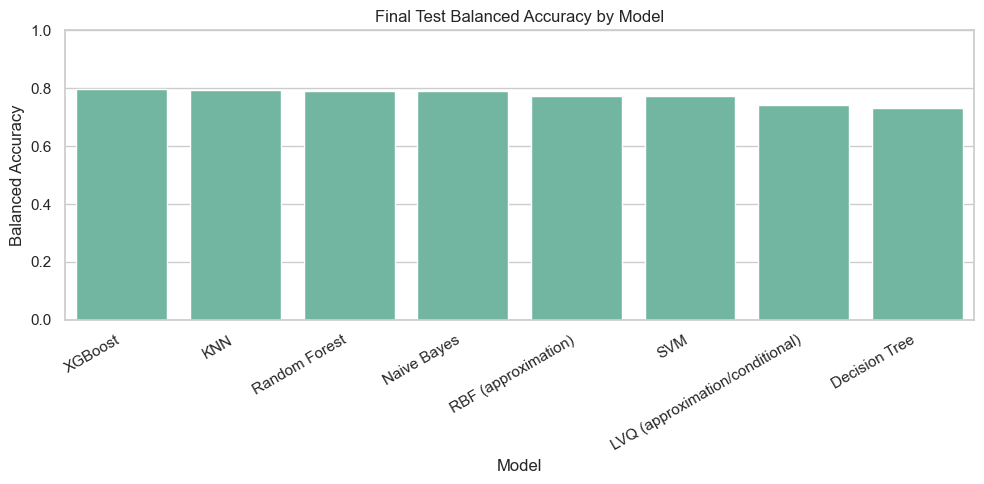

In [46]:
def auc_scores_a3(fitted_pipeline, X):
    if hasattr(fitted_pipeline, "predict_proba"):
        proba = fitted_pipeline.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] > 1:
            return proba[:, 1]
    if hasattr(fitted_pipeline, "decision_function"):
        return fitted_pipeline.decision_function(X)
    return None

def evaluate_pipeline_a3(model_name, fitted_pipeline):
    y_pred = fitted_pipeline.predict(X_test_retained_a3)
    tn, fp, fn, tp = confusion_matrix(y_test_a3, y_pred, labels=[0, 1]).ravel()
    score = auc_scores_a3(fitted_pipeline, X_test_retained_a3)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_a3, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test_a3, y_pred),
        "Precision": precision_score(y_test_a3, y_pred, zero_division=0),
        "Recall/Sensitivity": recall_score(y_test_a3, y_pred, zero_division=0),
        "Specificity": specificity_score_a3r(y_test_a3, y_pred),
        "F1-score": f1_score(y_test_a3, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_a3, score) if score is not None else np.nan,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

final_test_a3 = pd.DataFrame([
    evaluate_pipeline_a3(model_name, pipe)
    for model_name, pipe in best_final_pipelines_a3.items()
]).sort_values("Balanced Accuracy", ascending=False)

display(final_test_a3)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_test_a3, x="Model", y="Balanced Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Final Test Balanced Accuracy by Model")
plt.tight_layout()
plt.show()

#### Comparison: E0, E1, E2, E3, and Final Test

E0 represents the reported Assignment #2 baseline, while E1-E3 are evaluated using the Assignment #3 70:30 split and stratified 5-fold CV. Therefore, E0 vs E1 is a descriptive comparison and should not be interpreted as a controlled estimate of preprocessing effect.
Table 1 - Main E0-E3 Results


,Model,E0 Assignment 2 Baseline,E1 CV Mean,E1 CV Std,E2 CV Mean,E2 CV Std,Delta FS (E2-E1),FS Retained?,Configuration Entering E3,E3 CV Mean,E3 CV Std,Delta Tuning,Final Test Balanced Accuracy,Difference vs Assignment #2
0,Decision Tree,0.706,0.707,0.031,0.707,0.031,0.000,False,E1,0.764,0.029,0.057,0.733,0.027
1,KNN,0.823,0.762,0.018,0.763,0.015,0.001,False,E1,0.799,0.023,0.037,0.795,-0.028
2,LVQ (approximation/conditional),0.762,NaN,NaN,NaN,NaN,NaN,False,E1,NaN,NaN,NaN,0.743,-0.019
3,Naive Bayes,0.835,0.791,0.030,0.791,0.030,0.000,False,E1,0.792,0.032,0.002,0.792,-0.043
4,RBF (approximation),0.812,0.786,0.022,0.786,0.022,0.000,False,E1,0.801,0.032,0.015,0.774,-0.038
5,Random Forest,0.806,0.793,0.018,0.797,0.032,0.005,False,E1,0.813,0.028,0.021,0.792,-0.014
6,SVM,0.812,0.786,0.022,0.786,0.022,0.000,False,E1,0.801,0.032,0.015,0.774,-0.038
7,XGBoost,0.805,0.785,0.025,0.792,0.030,0.007,False,E1,0.815,0.035,0.030,0.797,-0.008


Improvement Contribution Table


,Model,E1 vs E0 Descriptive Difference,E0 Assignment 2 Baseline,Delta Feature Selection,Delta Tuning,FS Retained?,Final Test Balanced Accuracy,Final Test vs E0 Descriptive Difference
0,Decision Tree,0.001,0.706,0.000,0.057,False,0.733,0.027
1,KNN,-0.061,0.823,0.001,0.037,False,0.795,-0.028
2,LVQ (approximation/conditional),NaN,0.762,NaN,NaN,False,0.743,-0.019
3,Naive Bayes,-0.044,0.835,0.000,0.002,False,0.792,-0.043
4,RBF (approximation),-0.026,0.812,0.000,0.015,False,0.774,-0.038
5,Random Forest,-0.013,0.806,0.005,0.021,False,0.792,-0.014
6,SVM,-0.026,0.812,0.000,0.015,False,0.774,-0.038
7,XGBoost,-0.020,0.805,0.007,0.030,False,0.797,-0.008


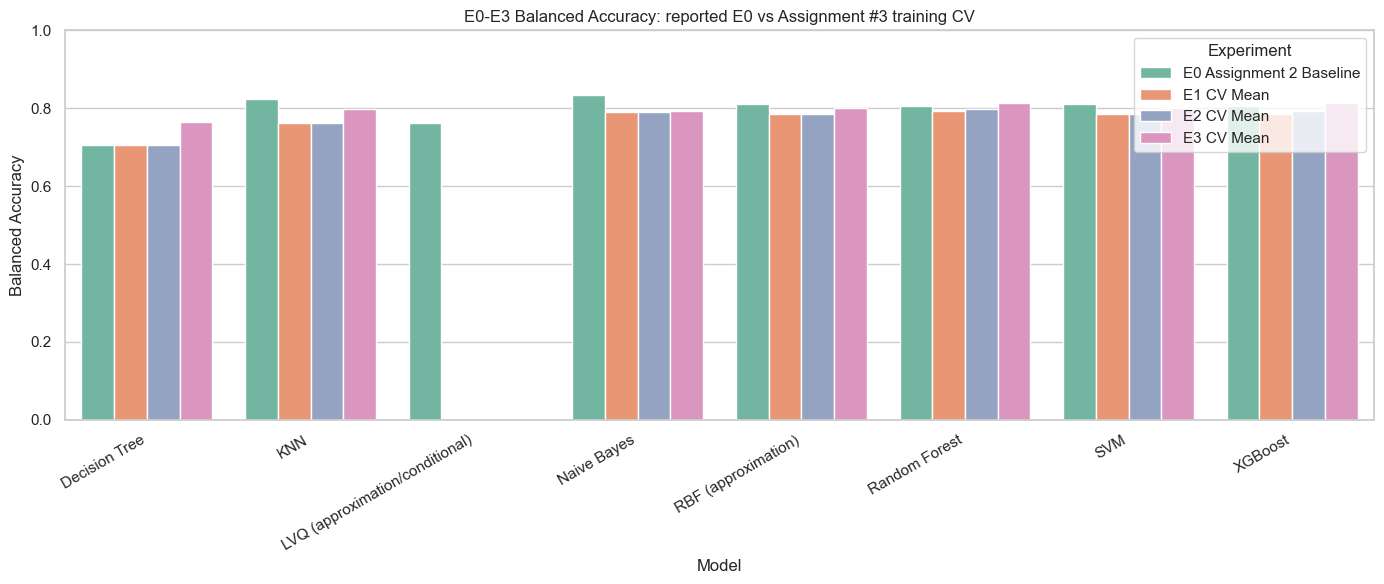

Caption: E0 is the reported Assignment #2 result and may use a different evaluation procedure; E1-E3 use the Assignment #3 training-only 5-fold CV.


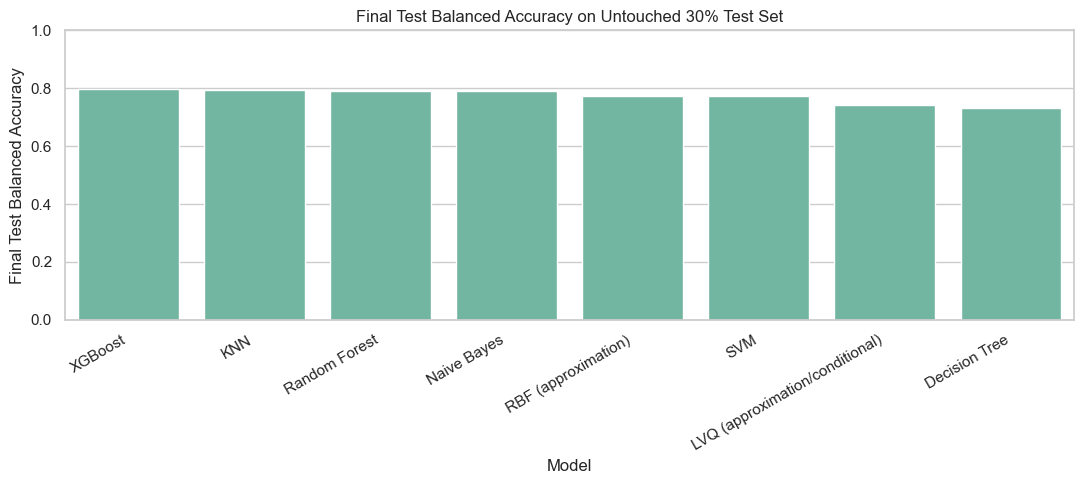

In [47]:
# E0 is the reported Assignment #2 result; it is not rerun here.
e0_reported_a3 = a2_baseline_a3[["Model", "A2 Balanced Accuracy"]].rename(
    columns={"A2 Balanced Accuracy": "E0 Assignment 2 Baseline"}
)

e1_summary_a3 = e1_results_a3[["Model", "balanced_accuracy_mean", "balanced_accuracy_std"]].rename(
    columns={
        "balanced_accuracy_mean": "E1 CV Mean",
        "balanced_accuracy_std": "E1 CV Std",
    }
)

e2_summary_main_a3 = e2_summary_a3[[
    "Model",
    "E2 CV Mean",
    "E2 CV Std",
    "Delta FS (E2-E1)",
    "FS Retained?",
]]

e3_summary_a3 = e3_results_a3[[
    "Model",
    "Configuration Entering E3",
    "Best CV Score",
    "CV Std",
    "Delta Tuning",
]].rename(columns={
    "Best CV Score": "E3 CV Mean",
    "CV Std": "E3 CV Std",
})

final_summary_a3 = final_test_a3[["Model", "Balanced Accuracy"]].rename(
    columns={"Balanced Accuracy": "Final Test Balanced Accuracy"}
)

main_e0_e3_results_a3 = (
    e0_reported_a3
    .merge(e1_summary_a3, on="Model", how="outer")
    .merge(e2_summary_main_a3, on="Model", how="outer")
    .merge(e3_summary_a3, on="Model", how="outer")
    .merge(final_summary_a3, on="Model", how="outer")
)
main_e0_e3_results_a3["Difference vs Assignment #2"] = (
    main_e0_e3_results_a3["Final Test Balanced Accuracy"]
    - main_e0_e3_results_a3["E0 Assignment 2 Baseline"]
)
main_e0_e3_results_a3 = main_e0_e3_results_a3[[
    "Model",
    "E0 Assignment 2 Baseline",
    "E1 CV Mean",
    "E1 CV Std",
    "E2 CV Mean",
    "E2 CV Std",
    "Delta FS (E2-E1)",
    "FS Retained?",
    "Configuration Entering E3",
    "E3 CV Mean",
    "E3 CV Std",
    "Delta Tuning",
    "Final Test Balanced Accuracy",
    "Difference vs Assignment #2",
]]

improvement_contribution_a3 = main_e0_e3_results_a3[[
    "Model",
    "E1 CV Mean",
    "E0 Assignment 2 Baseline",
    "Delta FS (E2-E1)",
    "Delta Tuning",
    "FS Retained?",
    "Final Test Balanced Accuracy",
    "Difference vs Assignment #2",
]].rename(columns={
    "E1 CV Mean": "E1 vs E0 Descriptive Difference",
    "Delta FS (E2-E1)": "Delta Feature Selection",
    "Difference vs Assignment #2": "Final Test vs E0 Descriptive Difference",
})
improvement_contribution_a3["E1 vs E0 Descriptive Difference"] = (
    main_e0_e3_results_a3["E1 CV Mean"]
    - main_e0_e3_results_a3["E0 Assignment 2 Baseline"]
)

print("E0 represents the reported Assignment #2 baseline, while E1-E3 are evaluated using the Assignment #3 70:30 split and stratified 5-fold CV. Therefore, E0 vs E1 is a descriptive comparison and should not be interpreted as a controlled estimate of preprocessing effect.")
print("Table 1 - Main E0-E3 Results")
display(main_e0_e3_results_a3)
print("Improvement Contribution Table")
display(improvement_contribution_a3)

cv_plot_data_a3r = main_e0_e3_results_a3.melt(
    id_vars="Model",
    value_vars=["E0 Assignment 2 Baseline", "E1 CV Mean", "E2 CV Mean", "E3 CV Mean"],
    var_name="Experiment",
    value_name="Balanced Accuracy",
)
plt.figure(figsize=(14, 6))
sns.barplot(data=cv_plot_data_a3r, x="Model", y="Balanced Accuracy", hue="Experiment")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("E0-E3 Balanced Accuracy: reported E0 vs Assignment #3 training CV")
plt.ylabel("Balanced Accuracy")
plt.tight_layout()
plt.show()

print("Caption: E0 is the reported Assignment #2 result and may use a different evaluation procedure; E1-E3 use the Assignment #3 training-only 5-fold CV.")

plt.figure(figsize=(11, 5))
sns.barplot(data=final_summary_a3, x="Model", y="Final Test Balanced Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Final Test Balanced Accuracy on Untouched 30% Test Set")
plt.tight_layout()
plt.show()


#### Detailed Metrics Tables for E0, E1, E2, E3, and Final Test

Bagian ini menampilkan semua metrik untuk semua model dalam tabel terpisah berdasarkan tahap eksperimen:

- `E0`: baseline Assignment #2.
- `E1`: improved preprocessing only, dievaluasi dengan Stratified 5-Fold CV pada training set.
- `E2`: improved preprocessing + model-specific feature selection, dievaluasi dengan Stratified 5-Fold CV pada training set.
- `E3`: improved preprocessing + selected feature configuration + tuned hyperparameters, dievaluasi ulang dengan Stratified 5-Fold CV pada training set.
- `Final Test`: final evaluation pada untouched 30% test set.

Untuk tabel CV (`E1`, `E2`, `E3`), setiap metrik ditampilkan sebagai mean dan standard deviation antar-fold.

In [48]:
# Detailed metrics tables for each experiment stage
def cv_metrics_table_a3r(results_df, stage_label):
    metric_pairs = [
        ("accuracy", "Accuracy"),
        ("balanced_accuracy", "Balanced Accuracy"),
        ("precision", "Precision"),
        ("recall", "Recall/Sensitivity"),
        ("specificity", "Specificity"),
        ("f1", "F1-score"),
        ("roc_auc", "ROC-AUC"),
    ]
    rows = []
    for _, row in results_df.iterrows():
        output = {"Stage": stage_label, "Model": row["Model"]}
        for raw_name, display_name in metric_pairs:
            mean_col = f"{raw_name}_mean"
            std_col = f"{raw_name}_std"
            output[f"{display_name} Mean"] = row.get(mean_col, np.nan)
            output[f"{display_name} Std"] = row.get(std_col, np.nan)
        rows.append(output)
    return pd.DataFrame(rows)


def cross_validate_final_tuned_models_a3r():
    rows = []
    for model_name, fitted_pipeline in best_final_pipelines_a3.items():
        cv_result = cross_validate(
            clone(fitted_pipeline),
            X_train_retained_a3,
            y_train_a3,
            cv=cv,
            scoring=scoring_a3,
            n_jobs=-1,
            error_score=np.nan,
        )
        row = {"Model": model_name, "Experiment": "E3 tuned CV all metrics"}
        for metric in scoring_a3:
            row[f"{metric}_mean"] = np.nanmean(cv_result[f"test_{metric}"])
            row[f"{metric}_std"] = np.nanstd(cv_result[f"test_{metric}"])
        rows.append(row)
    return pd.DataFrame(rows)

e0_metrics_table_a3 = a2_baseline_a3.rename(columns={
    "A2 Accuracy": "Accuracy",
    "A2 Balanced Accuracy": "Balanced Accuracy",
    "A2 Precision": "Precision",
    "A2 Recall": "Recall/Sensitivity",
    "A2 Specificity": "Specificity",
    "A2 F1": "F1-score",
}).copy()
e0_metrics_table_a3["Stage"] = "E0 Assignment #2 baseline"
e0_metrics_table_a3["ROC-AUC"] = np.nan
e0_metrics_table_a3 = e0_metrics_table_a3[[
    "Stage",
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC",
]]

e1_metrics_table_a3 = cv_metrics_table_a3r(e1_results_a3, "E1 preprocessing CV")
e2_metrics_table_a3 = cv_metrics_table_a3r(e2_results_a3, "E2 model-specific FS CV")
e3_cv_all_metrics_a3 = cross_validate_final_tuned_models_a3r()
e3_metrics_table_a3 = cv_metrics_table_a3r(e3_cv_all_metrics_a3, "E3 tuned CV")

final_test_metrics_table_a3 = final_test_a3.rename(columns={
    "Recall/Sensitivity": "Recall/Sensitivity",
    "F1-score": "F1-score",
}).copy()
final_test_metrics_table_a3["Stage"] = "Final untouched test"
final_test_metrics_table_a3 = final_test_metrics_table_a3[[
    "Stage",
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC",
    "TN",
    "FP",
    "FN",
    "TP",
]]

print("E0 - Assignment #2 Baseline Metrics")
display(e0_metrics_table_a3)

print("E1 - Improved Preprocessing Only: 5-Fold CV Metrics")
display(e1_metrics_table_a3)

print("E2 - Improved Preprocessing + Model-Specific Feature Selection: 5-Fold CV Metrics")
display(e2_metrics_table_a3)

print("E3 - Improved Preprocessing + Selected Features + Tuned Hyperparameters: 5-Fold CV Metrics")
display(e3_metrics_table_a3)

print("Final Test - Untouched 30% Test Set Metrics")
display(final_test_metrics_table_a3)

E0 - Assignment #2 Baseline Metrics


,Stage,Model,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC
0,E0 Assignment #2 baseline,Random Forest,0.808,0.806,0.829,0.824,0.789,0.826,NaN
1,E0 Assignment #2 baseline,Decision Tree,0.710,0.706,0.735,0.745,0.667,0.740,NaN
2,E0 Assignment #2 baseline,SVM,0.815,0.812,0.827,0.843,0.780,0.835,NaN
3,E0 Assignment #2 baseline,XGBoost,0.808,0.805,0.825,0.830,0.780,0.827,NaN
4,E0 Assignment #2 baseline,KNN,0.826,0.823,0.839,0.850,0.797,0.844,NaN
5,E0 Assignment #2 baseline,Naive Bayes,0.833,0.835,0.869,0.824,0.846,0.846,NaN
6,E0 Assignment #2 baseline,RBF (approximation),0.815,0.812,0.827,0.843,0.780,0.835,NaN
7,E0 Assignment #2 baseline,LVQ (approximation/conditional),0.764,0.762,0.789,0.784,0.740,0.787,NaN


E1 - Improved Preprocessing Only: 5-Fold CV Metrics


,Stage,Model,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall/Sensitivity Mean,Recall/Sensitivity Std,Specificity Mean,Specificity Std,F1-score Mean,F1-score Std,ROC-AUC Mean,ROC-AUC Std
0,E1 preprocessing CV,Random Forest,0.798,0.018,0.793,0.018,0.801,0.021,0.845,0.032,0.740,0.035,0.822,0.018,0.851,0.026
1,E1 preprocessing CV,Naive Bayes,0.793,0.030,0.791,0.030,0.811,0.028,0.817,0.035,0.764,0.040,0.814,0.028,0.865,0.024
2,E1 preprocessing CV,SVM,0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030
3,E1 preprocessing CV,RBF (approximation),0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030
4,E1 preprocessing CV,XGBoost,0.790,0.024,0.785,0.025,0.797,0.027,0.834,0.021,0.736,0.038,0.815,0.021,0.832,0.028
5,E1 preprocessing CV,KNN,0.770,0.018,0.762,0.018,0.767,0.016,0.840,0.026,0.684,0.028,0.801,0.017,0.822,0.024
6,E1 preprocessing CV,Decision Tree,0.710,0.029,0.707,0.031,0.741,0.036,0.733,0.037,0.681,0.060,0.736,0.027,0.707,0.031
7,E1 preprocessing CV,LVQ (approximation/conditional),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


E2 - Improved Preprocessing + Model-Specific Feature Selection: 5-Fold CV Metrics


,Stage,Model,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall/Sensitivity Mean,Recall/Sensitivity Std,Specificity Mean,Specificity Std,F1-score Mean,F1-score Std,ROC-AUC Mean,ROC-AUC Std
0,E2 model-specific FS CV,Random Forest,0.803,0.031,0.797,0.032,0.804,0.033,0.851,0.027,0.743,0.047,0.827,0.027,0.854,0.025
1,E2 model-specific FS CV,Decision Tree,0.710,0.029,0.707,0.031,0.741,0.036,0.733,0.037,0.681,0.060,0.736,0.027,0.707,0.031
2,E2 model-specific FS CV,SVM,0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030
3,E2 model-specific FS CV,XGBoost,0.797,0.030,0.792,0.030,0.806,0.026,0.831,0.033,0.754,0.033,0.819,0.028,0.837,0.026
4,E2 model-specific FS CV,KNN,0.770,0.016,0.763,0.015,0.772,0.015,0.829,0.028,0.698,0.024,0.799,0.016,0.816,0.015
5,E2 model-specific FS CV,Naive Bayes,0.793,0.030,0.791,0.030,0.811,0.028,0.817,0.035,0.764,0.040,0.814,0.028,0.865,0.024
6,E2 model-specific FS CV,RBF (approximation),0.795,0.021,0.786,0.022,0.783,0.023,0.871,0.013,0.702,0.037,0.825,0.016,0.864,0.030
7,E2 model-specific FS CV,LVQ (approximation/conditional),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


E3 - Improved Preprocessing + Selected Features + Tuned Hyperparameters: 5-Fold CV Metrics


,Stage,Model,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall/Sensitivity Mean,Recall/Sensitivity Std,Specificity Mean,Specificity Std,F1-score Mean,F1-score Std,ROC-AUC Mean,ROC-AUC Std
0,E3 tuned CV,Random Forest,0.820,0.025,0.813,0.025,0.814,0.024,0.873,0.022,0.753,0.034,0.843,0.022,0.863,0.031
1,E3 tuned CV,Decision Tree,0.767,0.022,0.764,0.026,0.791,0.042,0.792,0.033,0.736,0.074,0.790,0.015,0.777,0.036
2,E3 tuned CV,SVM,0.801,0.027,0.801,0.028,0.832,0.030,0.803,0.027,0.799,0.041,0.817,0.025,0.865,0.031
3,E3 tuned CV,XGBoost,0.818,0.030,0.815,0.032,0.829,0.036,0.848,0.029,0.781,0.054,0.838,0.025,0.868,0.032
4,E3 tuned CV,KNN,0.806,0.022,0.799,0.021,0.802,0.019,0.862,0.042,0.736,0.034,0.830,0.023,0.857,0.017
5,E3 tuned CV,Naive Bayes,0.795,0.028,0.792,0.028,0.813,0.025,0.817,0.035,0.767,0.034,0.815,0.027,0.865,0.024
6,E3 tuned CV,RBF (approximation),0.801,0.027,0.801,0.028,0.832,0.030,0.803,0.027,0.799,0.041,0.817,0.025,0.865,0.031
7,E3 tuned CV,LVQ (approximation/conditional),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Final Test - Untouched 30% Test Set Metrics


,Stage,Model,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
3,Final untouched test,XGBoost,0.801,0.797,0.814,0.830,0.764,0.822,0.895,94,29,26,127
4,Final untouched test,KNN,0.801,0.795,0.802,0.850,0.740,0.825,0.886,91,32,23,130
0,Final untouched test,Random Forest,0.797,0.792,0.805,0.837,0.748,0.821,0.893,92,31,25,128
5,Final untouched test,Naive Bayes,0.793,0.792,0.820,0.804,0.780,0.812,0.888,96,27,30,123
6,Final untouched test,RBF (approximation),0.772,0.774,0.821,0.752,0.797,0.785,0.883,98,25,38,115
2,Final untouched test,SVM,0.772,0.774,0.821,0.752,0.797,0.785,0.883,98,25,38,115
7,Final untouched test,LVQ (approximation/conditional),0.750,0.743,0.759,0.804,0.683,0.781,0.831,84,39,30,123
1,Final untouched test,Decision Tree,0.736,0.733,0.763,0.758,0.707,0.761,0.779,87,36,37,116


#### Cara Membaca Fitur Final Tiap Model

Setelah seluruh sel dijalankan, lihat tabel `per_model_summary_a3r`.

Kolom penting:

- `Feature selection method`: metode seleksi fitur yang dipakai model tersebut.
- `Selected original features`: fitur asli yang dipakai model.
- `Selected transformed features`: fitur aktual setelah preprocessing/one-hot encoding.
- `Best hyperparameters`: hyperparameter terbaik hasil CV.
- `CV tuned balanced accuracy`: performa CV setelah tuning.
- `Final test balanced accuracy`: performa final pada untouched test set.

#### Per-Model Final Summary

In [49]:
per_model_summary_a3 = pd.DataFrame([
    {
        "Model": model_name,
        "Dropped features (>30% missing)": features_dropped_missing_gt30_a3,
        "Scaling": "Yes" if model_name in scale_sensitive_models_a3 else "No",
        "Feature selection method": fs_design_a3.loc[fs_design_a3["Model"] == model_name, "Feature Selection"].iloc[0],
        "Transformed features before FS": best_fs_config_a3.get(model_name, {}).get("transformed_before", np.nan),
        "k tested": sorted(fs_search_results_a3.loc[fs_search_results_a3["Model"] == model_name, "k tested"].tolist()),
        "Selected original clinical features": selected_original_by_model_a3.get(model_name, "Tidak tersedia"),
        "Selected transformed features": selected_transformed_by_model_a3.get(model_name, "Tidak tersedia"),
        "FS Retained?": main_e0_e3_results_a3.loc[main_e0_e3_results_a3["Model"] == model_name, "FS Retained?"].iloc[0] if model_name in main_e0_e3_results_a3["Model"].values else np.nan,
        "Configuration entering E3": main_e0_e3_results_a3.loc[main_e0_e3_results_a3["Model"] == model_name, "Configuration Entering E3"].iloc[0] if model_name in main_e0_e3_results_a3["Model"].values else "Tidak tersedia",
        "Best hyperparameters": e3_results_a3.loc[e3_results_a3["Model"] == model_name, "Best Parameters"].iloc[0] if model_name in e3_results_a3["Model"].values else "Tidak tersedia",
        "CV tuned balanced accuracy": e3_results_a3.loc[e3_results_a3["Model"] == model_name, "Best CV Score"].iloc[0] if model_name in e3_results_a3["Model"].values else np.nan,
        "Final test balanced accuracy": final_test_a3.loc[final_test_a3["Model"] == model_name, "Balanced Accuracy"].iloc[0] if model_name in final_test_a3["Model"].values else np.nan,
    }
    for model_name in model_order_a3
])

table_a_missing_preprocessing_a3 = missing_a3.copy()
table_a_missing_preprocessing_a3["Preprocessing decision"] = np.where(
    table_a_missing_preprocessing_a3["Action"] == "DROP FEATURE",
    "Dropped before preprocessing",
    np.where(
        table_a_missing_preprocessing_a3["Feature"].isin(numerical_features_a3),
        "Median imputation",
        "Most-frequent imputation + one-hot",
    ),
)
table_b_feature_selection_a3 = e2_results_a3[[
    "Model",
    "FS method",
    "Transformed features before FS",
    "k tested",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "Selected transformed features",
    "Selected original clinical features",
]].rename(columns={
    "balanced_accuracy_mean": "CV mean",
    "balanced_accuracy_std": "CV std",
})
table_c_tuning_a3 = e3_results_a3.copy()
table_d_a2_vs_a3 = main_e0_e3_results_a3[[
    "Model",
    "E0 Assignment 2 Baseline",
    "Final Test Balanced Accuracy",
    "Difference vs Assignment #2",
]]

print("Table A - Missing/preprocessing decisions")
display(table_a_missing_preprocessing_a3)
print("Table B - Feature-selection results for eight models")
display(table_b_feature_selection_a3)
print("Table C - Hyperparameter-tuning results for eight models")
display(table_c_tuning_a3)
print("Table D - Assignment #2 baseline vs Assignment #3 final results")
display(table_d_a2_vs_a3)
print("Per-model final summary: original clinical features are reported separately from one-hot transformed columns.")
display(per_model_summary_a3)

Table A - Missing/preprocessing decisions


,Feature,Type,Missing Count Train,Missing Percentage Train,Action,Preprocessing decision
11,ca,None,429,66.615,DROP FEATURE,Dropped before preprocessing
12,thal,None,339,52.640,DROP FEATURE,Dropped before preprocessing
10,slope,None,203,31.522,DROP FEATURE,Dropped before preprocessing
4,chol,numeric,136,21.118,RETAIN + IMPUTE,Median imputation
5,fbs,binary,58,9.006,RETAIN + IMPUTE,Most-frequent imputation + one-hot
9,oldpeak,numeric,48,7.453,RETAIN + IMPUTE,Median imputation
3,trestbps,numeric,45,6.988,RETAIN + IMPUTE,Median imputation
8,exang,binary,43,6.677,RETAIN + IMPUTE,Most-frequent imputation + one-hot
7,thalach,numeric,43,6.677,RETAIN + IMPUTE,Median imputation
1,sex,binary,0,0.000,RETAIN + IMPUTE,Most-frequent imputation + one-hot


Table B - Feature-selection results for eight models


,Model,FS method,Transformed features before FS,k tested,CV mean,CV std,Selected transformed features,Selected original clinical features
0,Random Forest,SelectFromModel(RandomForest),15,"[3, 4, 5, 6, 8, 10, 12, 15]",0.797,0.032,"[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ..."
1,Decision Tree,RFE(DecisionTree),15,"[3, 4, 5, 6, 8, 10, 12, 15]",0.707,0.031,"[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ..."
2,SVM,RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]",0.786,0.022,"[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ..."
3,XGBoost,SelectFromModel(XGBoost),15,"[3, 4, 5, 6, 8, 10, 12, 15]",0.792,0.030,"[num__age, num__chol, num__thalach, num__oldpe...","[age, chol, cp, exang, fbs, oldpeak, restecg, ..."
4,KNN,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]",0.763,0.015,"[num__age, num__chol, num__thalach, num__oldpe...","[age, chol, cp, exang, oldpeak, restecg, thalach]"
5,Naive Bayes,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]",0.791,0.030,"[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ..."
6,RBF (approximation),RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]",0.786,0.022,"[num__age, num__trestbps, num__chol, num__thal...","[age, chol, cp, exang, fbs, oldpeak, restecg, ..."
7,LVQ (approximation/conditional),SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]",NaN,NaN,"[num__age, bin__exang, nom__cp_2.0]","[age, cp, exang]"


Table C - Hyperparameter-tuning results for eight models


,Model,FS Retained?,Configuration Entering E3,Selected k,Hyperparameter Search Space,Best Parameters,Best CV Score,CV Std,Reference CV Score,Delta Tuning
3,XGBoost,False,E1,12,"{'model__n_estimators': [100, 200], 'model__ma...","{'model__colsample_bytree': 1.0, 'model__learn...",0.815,0.035,0.785,0.030
0,Random Forest,False,E1,12,"{'model__n_estimators': [100, 200, 300], 'mode...","{'model__class_weight': None, 'model__max_dept...",0.813,0.028,0.793,0.021
2,SVM,False,E1,15,"{'model__C': [0.1, 1, 10, 50], 'model__gamma':...","{'model__C': 1, 'model__class_weight': 'balanc...",0.801,0.032,0.786,0.015
6,RBF (approximation),False,E1,15,"{'model__C': [0.1, 1, 10, 50], 'model__gamma':...","{'model__C': 1, 'model__class_weight': 'balanc...",0.801,0.032,0.786,0.015
4,KNN,False,E1,8,"{'model__n_neighbors': [3, 5, 7, 9, 11, 15], '...","{'model__n_neighbors': 15, 'model__p': 1, 'mod...",0.799,0.023,0.762,0.037
5,Naive Bayes,False,E1,15,"{'model__var_smoothing': [1e-10, 1e-09, 1e-08,...",{'model__var_smoothing': 1e-07},0.792,0.032,0.791,0.002
1,Decision Tree,False,E1,15,"{'model__criterion': ['gini', 'entropy'], 'mod...","{'model__class_weight': 'balanced', 'model__cr...",0.764,0.029,0.707,0.057
7,LVQ (approximation/conditional),False,E1,3,"[{'model__prototype_n_per_class': [1, 2], 'mod...","{'model__activation_type': 'identity', 'model_...",NaN,NaN,NaN,NaN


Table D - Assignment #2 baseline vs Assignment #3 final results


,Model,E0 Assignment 2 Baseline,Final Test Balanced Accuracy,Difference vs Assignment #2
0,Decision Tree,0.706,0.733,0.027
1,KNN,0.823,0.795,-0.028
2,LVQ (approximation/conditional),0.762,0.743,-0.019
3,Naive Bayes,0.835,0.792,-0.043
4,RBF (approximation),0.812,0.774,-0.038
5,Random Forest,0.806,0.792,-0.014
6,SVM,0.812,0.774,-0.038
7,XGBoost,0.805,0.797,-0.008


Per-model final summary: original clinical features are reported separately from one-hot transformed columns.


,Model,Dropped features (>30% missing),Scaling,Feature selection method,Transformed features before FS,k tested,Selected original clinical features,Selected transformed features,FS Retained?,Configuration entering E3,Best hyperparameters,CV tuned balanced accuracy,Final test balanced accuracy
0,Random Forest,"[ca, thal, slope]",No,SelectFromModel(RandomForest),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, chol, cp, exang, fbs, oldpeak, restecg, ...","[num__age, num__trestbps, num__chol, num__thal...",False,E1,"{'model__class_weight': None, 'model__max_dept...",0.813,0.792
1,Decision Tree,"[ca, thal, slope]",No,RFE(DecisionTree),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, chol, cp, exang, fbs, oldpeak, restecg, ...","[num__age, num__trestbps, num__chol, num__thal...",False,E1,"{'model__class_weight': 'balanced', 'model__cr...",0.764,0.733
2,SVM,"[ca, thal, slope]",Yes,RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, chol, cp, exang, fbs, oldpeak, restecg, ...","[num__age, num__trestbps, num__chol, num__thal...",False,E1,"{'model__C': 1, 'model__class_weight': 'balanc...",0.801,0.774
3,XGBoost,"[ca, thal, slope]",No,SelectFromModel(XGBoost),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, chol, cp, exang, fbs, oldpeak, restecg, ...","[num__age, num__chol, num__thalach, num__oldpe...",False,E1,"{'model__colsample_bytree': 1.0, 'model__learn...",0.815,0.797
4,KNN,"[ca, thal, slope]",Yes,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, chol, cp, exang, oldpeak, restecg, thalach]","[num__age, num__chol, num__thalach, num__oldpe...",False,E1,"{'model__n_neighbors': 15, 'model__p': 1, 'mod...",0.799,0.795
5,Naive Bayes,"[ca, thal, slope]",No,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, chol, cp, exang, fbs, oldpeak, restecg, ...","[num__age, num__trestbps, num__chol, num__thal...",False,E1,{'model__var_smoothing': 1e-07},0.792,0.792
6,RBF (approximation),"[ca, thal, slope]",Yes,RFE(LinearSVC),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, chol, cp, exang, fbs, oldpeak, restecg, ...","[num__age, num__trestbps, num__chol, num__thal...",False,E1,"{'model__C': 1, 'model__class_weight': 'balanc...",0.801,0.774
7,LVQ (approximation/conditional),"[ca, thal, slope]",Yes,SelectKBest(mutual information),15,"[3, 4, 5, 6, 8, 10, 12, 15]","[age, cp, exang]","[num__age, bin__exang, nom__cp_2.0]",False,E1,"{'model__activation_type': 'identity', 'model_...",NaN,0.743


#### Leakage Audit and Final Discussion

In [50]:
leakage_audit_a3 = pd.DataFrame([
    {"Check": "test set split before preprocessing", "Status": True},
    {"Check": "missing threshold computed from X_train only", "Status": True},
    {"Check": "imputation fitted inside CV pipeline", "Status": True},
    {"Check": "scaling fitted inside CV pipeline", "Status": True},
    {"Check": "feature selection fitted inside CV pipeline", "Status": True},
    {"Check": "hyperparameter tuning uses training/CV only", "Status": True},
    {"Check": "test set used only for final evaluation", "Status": True},
])
display(leakage_audit_a3)

discussion_a3 = {
    "Dropped features because missing >30% on training": features_dropped_missing_gt30_a3,
    "Models helped by model-specific FS": e2_summary_a3.loc[e2_summary_a3["Interpretation"] == "IMPROVED", "Model"].tolist(),
    "Models not meaningfully helped by FS": e2_summary_a3.loc[e2_summary_a3["Interpretation"] != "IMPROVED", ["Model", "Interpretation"]].to_dict("records"),
    "Best final model on untouched test": final_test_a3.iloc[0].to_dict() if len(final_test_a3) else "Tidak tersedia",
    "Interpretation rule": "Do not claim improvement when the mean difference is small relative to CV variability.",
}

for title, value in discussion_a3.items():
    print(f"\n{title}")
    display(value) if isinstance(value, (list, dict, pd.DataFrame)) else print(value)


,Check,Status
0,test set split before preprocessing,True
1,missing threshold computed from X_train only,True
2,imputation fitted inside CV pipeline,True
3,scaling fitted inside CV pipeline,True
4,feature selection fitted inside CV pipeline,True
5,hyperparameter tuning uses training/CV only,True
6,test set used only for final evaluation,True



Dropped features because missing >30% on training


['ca', 'thal', 'slope']


Models helped by model-specific FS


[]


Models not meaningfully helped by FS


[{'Model': 'Random Forest',
  'Interpretation': 'REJECT: no meaningful gain over E1'},
 {'Model': 'Decision Tree',
  'Interpretation': 'REJECT: no meaningful gain over E1'},
 {'Model': 'SVM', 'Interpretation': 'REJECT: no meaningful gain over E1'},
 {'Model': 'XGBoost', 'Interpretation': 'REJECT: no meaningful gain over E1'},
 {'Model': 'KNN', 'Interpretation': 'REJECT: no meaningful gain over E1'},
 {'Model': 'Naive Bayes',
  'Interpretation': 'REJECT: no meaningful gain over E1'},
 {'Model': 'RBF (approximation)',
  'Interpretation': 'REJECT: no meaningful gain over E1'},
 {'Model': 'LVQ (approximation/conditional)',
  'Interpretation': 'REJECT: no meaningful gain over E1'}]


Best final model on untouched test


{'Model': 'XGBoost',
 'Accuracy': 0.8007246376811594,
 'Balanced Accuracy': 0.7971465008767735,
 'Precision': 0.8141025641025641,
 'Recall/Sensitivity': 0.8300653594771242,
 'Specificity': 0.7642276422764228,
 'F1-score': 0.8220064724919094,
 'ROC-AUC': 0.8948403209522291,
 'TN': 94,
 'FP': 29,
 'FN': 26,
 'TP': 127}


Interpretation rule
Do not claim improvement when the mean difference is small relative to CV variability.


#### Perbandingan Accuracy E0-E3

Tabel ini membandingkan **accuracy** delapan model pada seluruh tahap eksperimen. E0 adalah reported Assignment #2 baseline, sedangkan E1-E3 menggunakan evaluasi Assignment #3 pada training set dengan Stratified 5-Fold CV. Nilai E3 berasal dari konfigurasi yang benar-benar dipilih untuk tuning, yaitu E1 atau E2 sesuai keputusan feature selection.

In [51]:
accuracy_e0_a3 = a2_baseline_a3[["Model", "A2 Accuracy"]].rename(
    columns={"A2 Accuracy": "E0 Assignment 2 Accuracy"}
)
accuracy_e1_a3 = e1_results_a3[["Model", "accuracy_mean", "accuracy_std"]].rename(
    columns={
        "accuracy_mean": "E1 CV Mean Accuracy",
        "accuracy_std": "E1 CV Std Accuracy",
    }
)
accuracy_e2_a3 = e2_results_a3[["Model", "accuracy_mean", "accuracy_std"]].rename(
    columns={
        "accuracy_mean": "E2 CV Mean Accuracy",
        "accuracy_std": "E2 CV Std Accuracy",
    }
)
accuracy_e3_a3 = e3_cv_all_metrics_a3[["Model", "accuracy_mean", "accuracy_std"]].rename(
    columns={
        "accuracy_mean": "E3 CV Mean Accuracy",
        "accuracy_std": "E3 CV Std Accuracy",
    }
)

accuracy_e0_e3_table_a3 = (
    accuracy_e0_a3
    .merge(accuracy_e1_a3, on="Model", how="outer")
    .merge(accuracy_e2_a3, on="Model", how="outer")
    .merge(accuracy_e3_a3, on="Model", how="outer")
)
accuracy_e0_e3_table_a3 = accuracy_e0_e3_table_a3.set_index("Model").reindex(model_order_a3).reset_index()

display(accuracy_e0_e3_table_a3)

,Model,E0 Assignment 2 Accuracy,E1 CV Mean Accuracy,E1 CV Std Accuracy,E2 CV Mean Accuracy,E2 CV Std Accuracy,E3 CV Mean Accuracy,E3 CV Std Accuracy
0,Random Forest,0.808,0.798,0.018,0.803,0.031,0.820,0.025
1,Decision Tree,0.710,0.710,0.029,0.710,0.029,0.767,0.022
2,SVM,0.815,0.795,0.021,0.795,0.021,0.801,0.027
3,XGBoost,0.808,0.790,0.024,0.797,0.030,0.818,0.030
4,KNN,0.826,0.770,0.018,0.770,0.016,0.806,0.022
5,Naive Bayes,0.833,0.793,0.030,0.793,0.030,0.795,0.028
6,RBF (approximation),0.815,0.795,0.021,0.795,0.021,0.801,0.027
7,LVQ (approximation/conditional),0.764,NaN,NaN,NaN,NaN,NaN,NaN
